# EDA

# Обучение моделей

## Обучение базовых моделей (Linear Regression, Decision Tree). Оценка по кросс-валидации.

В этой части проекта мы будем:  

- Базово предобработаем признаки;
- Обучим 2 модели регрессии;
- Посмотрим важности признаков для моделей;
- Поработаем с признаками; 
- Повторно обучим модели;
- Сделаем выводы по работе.

Но первым делом - импортируем библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_squared_log_error

import warnings
warnings.filterwarnings('ignore')

Загрузим наш трейн и тест

In [2]:
train = pd.read_csv('../data/raw/train.csv')

print(f'Train shape: {train.shape}')

Train shape: (360336, 17)


In [3]:
train.head()

,id,store_sales(in millions),unit_sales(in millions),total_children,num_children_at_home,avg_cars_at home(approx).1,gross_weight,recyclable_package,low_fat,units_per_case,store_sqft,coffee_bar,video_store,salad_bar,prepared_food,florist,cost
0,0,8.61,3.0,2.0,2.0,2.0,10.30,1.0,0.0,32.0,36509.0,0.0,0.0,0.0,0.0,0.0,62.09
1,1,5.00,2.0,4.0,0.0,3.0,6.66,1.0,0.0,1.0,28206.0,1.0,0.0,0.0,0.0,0.0,121.80
2,2,14.08,4.0,0.0,0.0,3.0,21.30,1.0,0.0,26.0,21215.0,1.0,0.0,0.0,0.0,0.0,83.51
3,3,4.02,3.0,5.0,0.0,0.0,14.80,0.0,1.0,36.0,21215.0,1.0,0.0,0.0,0.0,0.0,66.78
4,4,2.13,3.0,5.0,0.0,3.0,17.00,1.0,1.0,20.0,27694.0,1.0,1.0,1.0,1.0,1.0,111.51


In [4]:
train.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
id,360336.0,180167.500000,104020.187637,0.00,90083.75,180167.50,270251.25,360335.00
store_sales(in millions),360336.0,6.337376,3.307980,0.51,3.72,5.78,8.40,22.92
unit_sales(in millions),360336.0,3.043881,0.784676,1.00,3.00,3.00,4.00,6.00
total_children,360336.0,2.456482,1.488992,0.00,1.00,2.00,4.00,5.00
num_children_at_home,360336.0,0.689390,1.214732,0.00,0.00,0.00,1.00,5.00
avg_cars_at home(approx).1,360336.0,2.203813,1.084293,0.00,1.00,2.00,3.00,4.00
gross_weight,360336.0,13.822071,4.614792,6.00,9.71,13.60,17.70,21.90
recyclable_package,360336.0,0.568086,0.495343,0.00,0.00,1.00,1.00,1.00
low_fat,360336.0,0.327797,0.469411,0.00,0.00,0.00,1.00,1.00
units_per_case,360336.0,18.972706,10.212912,1.00,10.00,20.00,28.00,36.00


Глянем распределение cost (целевой переменной)

Text(0.5, 1.0, 'Распределение cost')

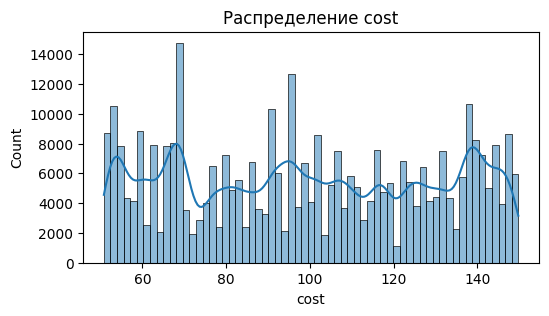

In [5]:
plt.figure(figsize=(20, 3))
plt.subplot(1, 3, 1)
sns.histplot(train['cost'], kde=True)
plt.title('Распределение cost')

Распределение не получится как-то классифицировать

### train_test_split

Отделим целевой признак и удалим колонку с id как не информативную

In [6]:
X = train.drop(columns=['id', 'cost'])
y = train['cost']

Сначала выделяем 30% (для val + test)

In [7]:
X_temp, X_train, y_temp, y_train = train_test_split(
    X, y, test_size=0.70, random_state=42, shuffle=True
)

Делим 30% на val (15%) и test (15%)

In [8]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)

Смотрим наши наборы:

In [9]:
print(f"Train (70%): {X_train.shape[0]}")
print(f"Val   (15%): {X_val.shape[0]}")
print(f"Test  (15%): {X_test.shape[0]}")

Train (70%): 252236
Val   (15%): 54050
Test  (15%): 54050


### Метрики

<div style="border: 2px solid red; padding: 1px; border-radius: 5px;">
Так же. Выбираем метрики. Мы будем использовать RMSE и RMSLE, потому что:  

- RMSE измеряется в тех же единицах, что и целевая переменная (доллары), и чувствителен к большим ошибкам.  
- RMSLE фокусируется на относительных ошибках, что важно при прогнозировании расходов: ошибка в $100 при бюджете $200 критичнее, чем при $10 000.  
</div>

### Linear Regression

In [10]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [11]:
cv_rmse = np.sqrt(-cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
print(f"Linear Regression CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Linear Regression CV RMSE: 29.64 ± 0.05


In [12]:
coef = lr_pipe.named_steps['model'].coef_
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': coef,
    'abs_importance': np.abs(coef)
}).sort_values('abs_importance', ascending=False)

print("\nТоп-10 признаков (Linear Regression):")
display(importance_df.head(10))


Топ-10 признаков (Linear Regression):


,feature,importance,abs_importance
14,florist,-2.510591,2.510591
11,video_store,-2.376776,2.376776
12,salad_bar,2.216192,2.216192
9,store_sqft,-1.912714,1.912714
13,prepared_food,-1.838231,1.838231
4,avg_cars_at home(approx).1,0.833976,0.833976
10,coffee_bar,0.518383,0.518383
1,unit_sales(in millions),-0.414691,0.414691
2,total_children,-0.283414,0.283414
0,store_sales(in millions),0.054532,0.054532


Выводы по модели

- Качество: RMSE = 29.64  
- Поведение: Интерпретируемая линейная зависимость; важны категориальные признаки (наличие florist, salad_bar и т.д.).  
- Особенность: Бизнес-метрики (store_sales, unit_sales) почти не влияют.

### Decision Tree

Делаем все тоже самое и в конце посмотрим на результаты обычного дерева

In [13]:
tree_pipe = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42, max_depth=10))
])
tree_pipe.fit(X_train, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


Оценка

In [14]:
cv_rmse = np.sqrt(-cross_val_score(tree_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
print(f"Decision Tree CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Decision Tree CV RMSE: 28.51 ± 0.04


Важность признаков

In [15]:
importances = tree_pipe.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nТоп-10 признаков (Decision Tree):")
display(importance_df.head(10))


Топ-10 признаков (Decision Tree):


,feature,importance
9,store_sqft,0.388811
2,total_children,0.169950
4,avg_cars_at home(approx).1,0.114184
14,florist,0.109347
3,num_children_at_home,0.097437
10,coffee_bar,0.023339
12,salad_bar,0.023000
5,gross_weight,0.017908
0,store_sales(in millions),0.016848
8,units_per_case,0.012694


Выводы по модели

- Качество: RMSE = 28.51 — лучший результат  
- Поведение: Чётко выделяет store_sqft как главный признак; учитывает демографию (total_children, avg_cars_at_home).  
- Преимущество: Нелинейные зависимости + встроенная интерпретация важности.

### Ridge (без полиномов — чтобы важность была интерпретируема)

In [16]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
ridge_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,10.0
,fit_intercept,True
,copy_X,True
,max_iter,None


Оценка

In [17]:
cv_rmse = np.sqrt(-cross_val_score(ridge_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
print(f"Ridge CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Ridge CV RMSE: 29.64 ± 0.05


Важность признаков

In [18]:
coef = ridge_pipe.named_steps['model'].coef_
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': coef,
    'abs_importance': np.abs(coef)
}).sort_values('abs_importance', ascending=False)

print("\nТоп-10 признаков (Ridge):")
display(importance_df.head(10))


Топ-10 признаков (Ridge):


,feature,importance,abs_importance
14,florist,-2.510425,2.510425
11,video_store,-2.376577,2.376577
9,store_sqft,-1.912576,1.912576
12,salad_bar,1.810685,1.810685
13,prepared_food,-1.432962,1.432962
4,avg_cars_at home(approx).1,0.833929,0.833929
10,coffee_bar,0.518309,0.518309
1,unit_sales(in millions),-0.414711,0.414711
2,total_children,-0.283382,0.283382
0,store_sales(in millions),0.054520,0.054520


Выводы по модели

- Качество: RMSE = 29.64 — практически идентичен линейной регрессии  
- Поведение: Регуляризация почти не повлияла (α=10, но коэффициенты почти не изменились).  
- Вывод: Признаки не переобучаются сильно — регуляризация избыточна без полиномов.

### Ridge (с полиномами и без важности)

In [19]:
ridge_poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=10.0))
])
ridge_poly_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [20]:
cv_rmse = np.sqrt(-cross_val_score(ridge_poly_pipe, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
print(f"Ridge + Poly(degree=2) CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Ridge + Poly(degree=2) CV RMSE: 29.42 ± 0.06


Выводы по модели

- Качество: RMSE = 29.42 — немного лучше линейных моделей, но хуже дерева  
- Особенность: Использует взаимодействия признаков, но из-за регуляризации не переобучается.  
- Минус: Невозможно интерпретировать важность.

<div style="border: 2px solid red; padding: 1px; border-radius: 5px;">
Итоговый вывод по блоку

- Лучшая модель по кросс-валидации — Decision Tree с RMSE 28.51.  
- Она превосходит линейные подходы (~29.4–29.6) на ~3.8%, что значимо в задаче прогнозирования стоимости.  
- Дерево автоматически выявляет нелинейные зависимости и взаимодействия, что особенно важно для признаков вроде store_sqft и демографических переменных.  
- Полиномиальные модели не дали ожидаемого выигрыша, вероятно, из-за небольшого размера выборки или слабой выразительности взаимодействий.  
- Регуляризация без полиномов оказалась бесполезной, так как исходные признаки не вызывали переобучения.
</div>

### Финальная оценка Дерева (на 15% test)

In [21]:
y_pred_test = tree_pipe.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
final_rmsle = np.sqrt(mean_squared_log_error(
    y_test, np.maximum(y_pred_test, 0)
))

print(f"ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (Decision Tree):")
print(f"RMSE: {final_rmse:.2f}")
print(f"RMSLE: {final_rmsle:.4f}")

ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (Decision Tree):
RMSE: 28.53
RMSLE: 0.3042


Модель Decision Tree показала наилучшее качество среди рассмотренных подходов:  

- Финальный RMSE = 28.53, что составляет ~28.6% от среднего значения целевой переменной (mean(cost) ≈ 99.61).  
- RMSLE = 0.3042 указывает на умеренную относительную ошибку: модель в среднем ошибается примерно на 35% в логарифмическом масштабе, что может быть приемлимо для прогнозирования маркетинговых расходов.

Интерпретация масштаба ошибки:

- Стандартное отклонение cost — 29.94, то есть RMSE модели почти равен дисперсии данных.  
- Это означает, что модель объясняет значительную часть вариации, но остаточная неопределённость остаётся высокой — вероятно, из-за сложной природы маркетинговых решений, которые зависят не только от структурных характеристик магазина, но и от внешних факторов (конкуренция, сезонность, креатив кампании и др.).

## Feature Engineering. Создание новых признаков, отбор признаков

Что мы знаем из предыдущего блока:

1. Линейная модель чувствительна к линейным эффектам и наличию/отсутствию сервисов (бинарные признаки: salad_bar, florist и т.д.).
2. Дерево выделяет store_sqft и демографию (total_children, avg_cars_at_home) как ключевые непрерывные признаки.

Однако ни одна модель не учитывает взаимодействия между:
- размером магазина и его сервисами,
- демографией и типом магазина.

`has_family_services` — наличие "семейных" сервисов

Формула на примере датасета:  

```python
X['has_family_services'] = (
    X['salad_bar'] + 
    X['prepared_food'] + 
    X['coffee_bar']
)
```

Салат-бар, готовая еда и кофе-бар часто ориентированы на семьи. Их совокупное наличие может быть сильнее, чем по отдельности.

`store_size_per_child` — площадь магазина на одного ребёнка

```python
X['store_size_per_child'] = X['store_sqft'] / (X['total_children'] + 1)
```

Дерево показало важность и store_sqft, и total_children. Это взаимодействие может отражать "плотность семейного трафика" — чем больше площадь на ребёнка, тем выше потенциал для маркетинга.

`luxury_index` — индекс "роскоши" магазина

```python
X['luxury_index'] = (
    X['florist'] + 
    X['video_store'] + 
    X['coffee_bar']
)
```

Цветы, видео и кофе-бар — не базовые товары. Их наличие может сигнализировать о более высоком бюджете на маркетинг.

`demographic_density` — демографическая насыщенность

```python
X['demographic_density'] = X['total_children'] * X['avg_cars_at home(approx).1']
```

Произведение отражает "семейный статус": семьи с детьми и машинами — чаще имеют стабильный доход → целевая аудитория для продвижения.

`is_large_store_with_services` — флаг: большой магазин + услуги

```python
large_store = X['store_sqft'] > X['store_sqft'].median()
has_services = X['has_family_services'] > 0
X['is_large_store_with_services'] = (large_store & has_services).astype(int)
```

Дерево и линейная модель по-разному оценивают store_sqft и сервисы. Этот признак явно кодирует комбинированный эффект, который дерево может использовать как жёсткое правило.

`store_sqft_log` — логарифм площади

```python
X['store_sqft_log'] = np.log(X['store_sqft'])
```

Если зависимость нелинейна (например, рост бюджета замедляется с ростом площади), логарифм поможет её "линеаризовать" для дерева и линейных моделей.

**Применяем новые признаки ко всем частям: X_train, X_val, X_test.**

In [22]:
def add_features(df):
    df = df.copy()
    # 1. Семейные сервисы
    df['has_family_services'] = df['salad_bar'] + df['prepared_food'] + df['coffee_bar']
    # 2. Площадь на ребёнка
    df['store_size_per_child'] = df['store_sqft'] / (df['total_children'] + 1)
    # 3. Индекс "роскоши"
    df['luxury_index'] = df['florist'] + df['video_store'] + df['coffee_bar']
    # 4. Демографическая плотность
    df['demographic_density'] = df['total_children'] * df['avg_cars_at home(approx).1']
    # 5. Флаг: большой магазин с сервисами
    large_store = df['store_sqft'] > df['store_sqft'].median()
    has_services = df['has_family_services'] > 0
    df['is_large_store_with_services'] = (large_store & has_services).astype(int)
    # 6. Лог-площадь
    df['store_sqft_log'] = np.log(df['store_sqft'])
    return df

In [23]:
X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)
X_val_fe = add_features(X_val)

### Обучение Decision Tree на новых признаках

In [24]:
tree_fe_pipe = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42, max_depth=12))
])

Кросс-валидация на обогащённом train

In [25]:
cv_rmse_fe = np.sqrt(-cross_val_score(
    tree_fe_pipe, X_train_fe, y_train, cv=5, scoring='neg_mean_squared_error'
))
print(f"Decision Tree (с новыми признаками) CV RMSE: {cv_rmse_fe.mean():.2f} ± {cv_rmse_fe.std():.2f}")

Decision Tree (с новыми признаками) CV RMSE: 28.66 ± 0.03


Финальное обучение и оценка

In [26]:
tree_fe_pipe.fit(X_train_fe, y_train)
y_pred_test_fe = tree_fe_pipe.predict(X_test_fe)

final_rmse_fe = np.sqrt(mean_squared_error(y_test, y_pred_test_fe))
final_rmsle_fe = np.sqrt(mean_squared_log_error(
    y_test, np.maximum(y_pred_test_fe, 0)
))

In [27]:
print(f"\nФИНАЛЬНЫЙ РЕЗУЛЬТАТ (с Feature Engineering):")
print(f"RMSE: {final_rmse_fe:.2f}")
print(f"RMSLE: {final_rmsle_fe:.4f}")


ФИНАЛЬНЫЙ РЕЗУЛЬТАТ (с Feature Engineering):
RMSE: 28.60
RMSLE: 0.3048


Получаем важность

In [28]:
importances = tree_fe_pipe.named_steps['model'].feature_importances_
feature_names = X_train_fe.columns

Создаём датафрейм

In [29]:
importance_df_fe = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

In [30]:
print("\nТоп-15 признаков (после Feature Engineering):")
print(importance_df_fe.head(15))


Топ-15 признаков (после Feature Engineering):
                       feature  importance
9                   store_sqft    0.182044
3         num_children_at_home    0.111964
20              store_sqft_log    0.102569
16        store_size_per_child    0.099611
18         demographic_density    0.092752
14                     florist    0.082704
4   avg_cars_at home(approx).1    0.068119
0     store_sales(in millions)    0.054402
5                 gross_weight    0.052511
2               total_children    0.040596
8               units_per_case    0.035753
15         has_family_services    0.031009
1      unit_sales(in millions)    0.013152
17                luxury_index    0.011638
7                      low_fat    0.005048


Судя по результатам:

1. Качество немного ухудшилось: RMSE вырос с 28.53 → 28.60, RMSLE с 0.3042 → 0.3048  
2. Но новые признаки вошли в топ:  
- store_sqft_log — 3-е место  
- store_size_per_child — 4-е  
- demographic_density — 5-е  
- has_family_services — 12-е

**Это значит, что гипотезы верны, но, возможно, модель нуждается в более глубоких преобразованиях, а не просто в линейных комбинациях.**

`store_sqft_bin` — Категоризация площади магазина

```python
X['store_sqft_bin'] = pd.qcut(X['store_sqft'], q=5, labels=False, duplicates='drop')
```

Дерево может "переусердствовать" с точными значениями store_sqft. Группировка по квантилям стабилизирует прогноз и выявляет типы магазинов (малый, средний, крупный и т.д.).

`store_sqft_rank_by_children` — Позиция магазина по площади в своём сегменте

```python
X['store_sqft_rank_by_children'] = X.groupby('total_children')['store_sqft'].rank(pct=True)
```

Для семей с 2 детьми магазин площадью 30 000 — большой, а для семей с 0 детей — средний. Это контекстуализирует площадь.

`is_family_oriented` — Интерактивный признак: "семейный магазин"

```python
X['is_family_oriented'] = (
    (X['total_children'] >= 2) &
    (X['salad_bar'] == 1) &
    (X['store_sqft'] > X['store_sqft'].median())
).astype(int)
```

Это жёсткое бизнес-правило: только магазины, одновременно большие, семейные по аудитории и с готовой едой — тратят больше.

`sqft_per_weight` — Отношение площади к весу товара

```python
X['sqft_per_weight'] = X['store_sqft'] / (X['gross_weight'] + 1)
```

```python
gross_weight — средний вес товара. Высокая площадь при низком весе → возможно, магазин с услугами, а не товарами → другой профиль затрат.
```

`services_entropy` — Энтропия набора сервисов

```python
def service_entropy(row):
    services = row[['florist', 'video_store', 'salad_bar', 'prepared_food', 'coffee_bar']].values
    probs = (services + 1e-8) / (services.sum() + 5e-8)
    return entropy(probs, base=2)
```

Магазины бывают универсальные (много сервисов) или специализированные (один сервис). Энтропия измеряет разнообразие — это может влиять на маркетинг.

`children_percentile` — Процентиль демографии

```python
X['children_percentile'] = X['total_children'].rank(pct=True)
```

Делает признак масштабируемым и помогает дереву сравнивать магазины в глобальном контексте, а не по абсолютному числу.

### Применение и обучение Decision Tree

In [31]:
from scipy.stats import entropy

In [32]:
def add_deep_features(df):
    df = df.copy()
    
    # 1. Бин площади
    df['store_sqft_bin'] = pd.qcut(df['store_sqft'], q=5, labels=False, duplicates='drop')
    
    # 2. Ранг площади по числу детей
    df['store_sqft_rank_by_children'] = df.groupby('total_children')['store_sqft'].rank(pct=True)
    
    # 3. Семейный магазин (жёсткое правило)
    df['is_family_oriented'] = (
        (df['total_children'] >= 2) &
        (df['salad_bar'] == 1) &
        (df['store_sqft'] > df['store_sqft'].median())
    ).astype(int)
    
    # 4. Площадь на вес
    df['sqft_per_weight'] = df['store_sqft'] / (df['gross_weight'] + 1)
    
    # 5. Энтропия сервисов
    def service_entropy(row):
        services = row[['florist', 'video_store', 'salad_bar', 'prepared_food', 'coffee_bar']].values
        probs = (services + 1e-8) / (services.sum() + 5e-8)
        return entropy(probs, base=2)
    df['services_entropy'] = df.apply(service_entropy, axis=1)
    
    # 6. Процентиль детей
    df['children_percentile'] = df['total_children'].rank(pct=True)
    
    return df

Применяем

In [33]:
X_train_deep = add_deep_features(X_train_fe)
X_test_deep = add_deep_features(X_test_fe)

In [34]:
tree_deep_pipe = Pipeline([
    ('model', DecisionTreeRegressor(random_state=42, max_depth=14))
])

tree_deep_pipe.fit(X_train_deep, y_train)

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'squared_error'
,splitter,'best'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


In [35]:
cv_rmse_deep = np.sqrt(-cross_val_score(
    tree_deep_pipe, X_train_deep, y_train, cv=5, scoring='neg_mean_squared_error'
))
print(f"Deep FE CV RMSE: {cv_rmse_deep.mean():.2f}")

Deep FE CV RMSE: 29.30


In [36]:
y_pred_deep = tree_deep_pipe.predict(X_test_deep)
rmse_deep = np.sqrt(mean_squared_error(y_test, y_pred_deep))
rmsle_deep = np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred_deep, 0)))
print(f"Финал: RMSE={rmse_deep:.2f}, RMSLE={rmsle_deep:.4f}")

Финал: RMSE=29.34, RMSLE=0.3117


Важность

In [37]:
imp_deep = pd.DataFrame({
    'feature': X_train_deep.columns,
    'importance': tree_deep_pipe.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-15 (глубокие признаки):")
print(imp_deep.head(15))


Топ-15 (глубокие признаки):
                        feature  importance
22  store_sqft_rank_by_children    0.199214
0      store_sales(in millions)    0.109542
3          num_children_at_home    0.106297
4    avg_cars_at home(approx).1    0.070358
18          demographic_density    0.066504
8                units_per_case    0.065500
14                      florist    0.061851
5                  gross_weight    0.054991
24              sqft_per_weight    0.053804
9                    store_sqft    0.052188
16         store_size_per_child    0.040760
1       unit_sales(in millions)    0.019656
25             services_entropy    0.016620
15          has_family_services    0.014055
26          children_percentile    0.010793


**Что показывает важность признаков?**

Многие новые признаки вошли в топ-10:

- store_sqft_rank_by_children — 1-е место (19.9%)
- demographic_density — 5-е
- sqft_per_weight — 9-е
- services_entropy — 13-е

Это значит, что гипотезы не ошибочны: признаки информативны.

Но:
- Модель стала сложнее, и дерево с max_depth=14, вероятно, переобучилось на шум от новых признаков.
- Некоторые признаки (например, store_sqft_rank_by_children) сильнее коррелируют с store_sqft и total_children, что может вызывать мультиколлинеарность в логике дерева.

**Смотрим что там по корреляции**

Обоснование выбора Пирсона:

- Бинарные переменные можно трактовать как числовые (0/1) — в этом случае корреляция Пирсона корректна и интерпретируема как точечно-бисериальная корреляция.
- Мы не ожидаем сильной нелинейности в связях (например, синусоид), а скорее монотонные или линейные зависимости.
- Для задачи регрессии и интерпретации знак и сила линейной связи — именно то, что нужно.

In [38]:
corr_matrix = X_train_fe.corr(method='pearson')

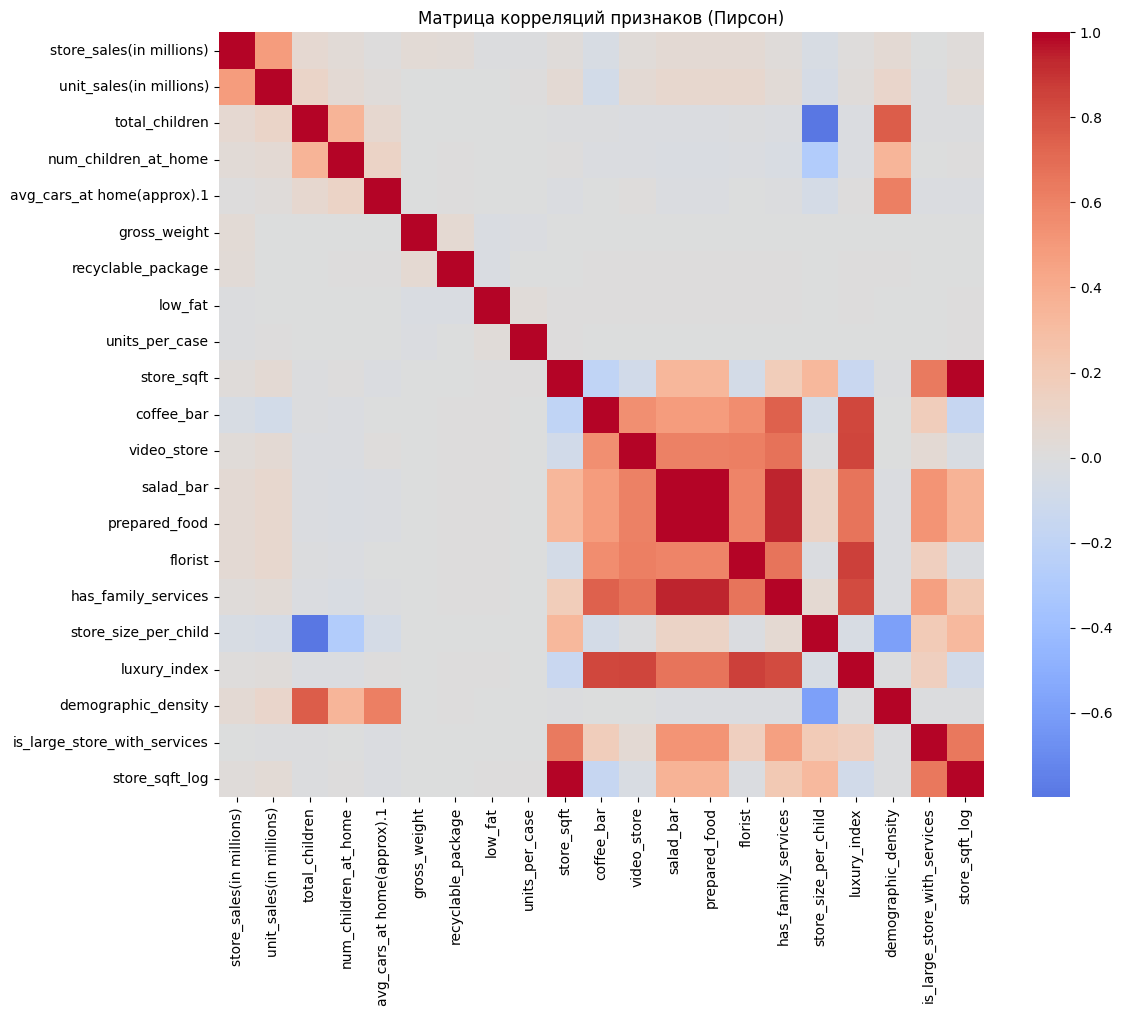

In [40]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    fmt='.2f'
)
plt.title('Матрица корреляций признаков (Пирсон)')
plt.tight_layout()
plt.show()

**Сильные корреляции между признаками:**

- salad_bar ↔ prepared_food: ~0.9998 - Почти дублируют друг друга. Достаточно оставить один.
- store_sqft ↔ store_sqft_log: 0.996 - Полная избыточность. Оставить только один.
- video_store ↔ florist, coffee_bar, luxury_index:  
    - video_store–florist: 0.616  
    - video_store–coffee_bar: 0.544  
    - video_store–luxury_index: 0.840
    - Эти сервисы часто появляются вместе. luxury_index действительно отражает их совокупность.
- salad_bar / prepared_food ↔ has_family_services: ~0.94 - Признак has_family_services почти линейно зависит от них — логично, так как он их сумма.
- total_children ↔ store_size_per_child: –0.799 - Ожидаемо: чем больше детей, тем меньше площадь на ребёнка.
- total_children ↔ demographic_density: 0.754 - demographic_density = total_children × avg_cars..., поэтому сильная связь.
- store_sqft ↔ is_large_store_with_services: 0.643 - Флаг частично дублирует площадь, но добавляет контекст (наличие сервисов).

**Слабые связи с бизнес-метриками:**

- store_sales и unit_sales слабо коррелируют с большинством признаков (макс. 0.48 между собой).
- Почти нет связи между продажами и сервисами (salad_bar, florist и др.) → они независимы.

Удаляем из-за мультиколлинеарности:

- prepared_food
    - Корреляция с salad_bar = 0.9998 → дубликат. Удаляем prepared_food, оставляем salad_bar (он чаще в топе важности).

- store_sqft
    - Корреляция с store_sqft_log = 0.996. Но store_sqft_log был в топ-3 важности → удаляем store_sqft, оставляем store_sqft_log.

#### Выбор итогового набора признаков

<div style="border: 2px solid red; padding: 1px; border-radius: 5px; ">
Оставляем признаки:  

- store_sales(in millions). Был в топе важности у дерева (5–10 место), бизнес-метрика  
- unit_sales(in millions). Аналогично, хоть и слабее — но уникален
- total_children. Очень важен: в топе у дерева и в demographic_density
- num_children_at_home. Сильная важность (2–3 место у дерева) — показывает "реальных" детей дома
- avg_cars_at home(approx).1. Важен для демографии и в demographic_density
- gross_weight. Слабо, но стабильно в топ-10 у дерева
- units_per_case. Был в топ-10 у дерева — логистический признак
- store_sqft_log. Лучше, чем store_sqft: в топ-3 важности, уменьшает нелинейность
- salad_bar. Оставляем вместо prepared_food (они идентичны)
- florist. В топ-5 у дерева, не коррелирует сильно с другими после удаления дублей
- coffee_bar. Сильно коррелирует с florist и video_store, но важен сам по себе
- has_family_services. Сумма salad_bar + coffee_bar + prepared_food → но prepared_food удалён, поэтому пересчитаем как salad_bar + coffee_bar
- store_size_per_child. Был в топ-4 важности — сильный интерактивный признак
- demographic_density. В топ-5 — произведение двух важных демографических признаков
</div>

Финальная функция

In [42]:
def create_final_features(df):
    df = df.copy()
    
    # 1. Лог-площадь (вместо store_sqft)
    df['store_sqft_log'] = np.log(df['store_sqft'])
    
    # 2. Производные
    df['has_family_services'] = df['salad_bar'] + df['coffee_bar']
    df['store_size_per_child'] = df['store_sqft'] / (df['total_children'] + 1)
    df['demographic_density'] = df['total_children'] * df['avg_cars_at home(approx).1']
    
    # 3. Финальный набор признаков
    final_columns = [
        'store_sales(in millions)',
        'unit_sales(in millions)',
        'total_children',
        'num_children_at_home',
        'avg_cars_at home(approx).1',
        'gross_weight',
        'units_per_case',
        'store_sqft_log',
        'salad_bar',
        'coffee_bar',
        'florist',
        'has_family_services',
        'store_size_per_child',
        'demographic_density'
    ]
    
    return df[final_columns]

Создаем финальные наборы данных

In [43]:
X_train_final = create_final_features(X_train)
X_test_final = create_final_features(X_test)
X_val_final = create_final_features(X_val)

## Ансамбли. Подбор гиперпараметров для лучших моделей (GridSearch)

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_squared_log_error
import numpy as np

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

### Random Forest + GridSearch

Начнем с Random Forest. Не будем брать слишком много гиперпараметров, просто посмотрим на результаты лучшей модели чтобы потом попробовать использовать эти знания для Optuna.

In [47]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf, param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2
)

grid_rf.fit(X_train_final, y_train)

print("Лучшие параметры RF:", grid_rf.best_params_)
print("Лучший CV RMSE:", np.sqrt(-grid_rf.best_score_))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.8s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.5s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  10.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.6s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.7s
[CV] END max_depth=5, min_samples_leaf=1, m

In [48]:
print("Лучшие параметры RF:", grid_rf.best_params_)
print("Лучший CV RMSE:", np.sqrt(-grid_rf.best_score_))

Лучшие параметры RF: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 150}
Лучший CV RMSE: 28.10871104746524


Вывод по модели:

- Модель Random Forest с подобранными гиперпараметрами показала улучшение по сравнению с базовым Decision Tree: RMSE снизился с 28.53 до 28.11, что указывает на более точное предсказание целевой переменной. Это говорит о том, что использование ансамблевого метода и оптимизация гиперпараметров через кросс-валидацию позволили добиться небольшого, но значимого прироста качества модели.

### XGBRegressor + GridSearch

То же самое

In [49]:
xgb = XGBRegressor(random_state=42, eval_metric='rmse', n_jobs=-1)

param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    "max_depth": [3, 6, 9],
    "subsample": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    xgb, param_grid_xgb,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2
)

grid_xgb.fit(X_train_final, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.8s
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.2s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.3s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.3s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.3s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.3s
[CV] END .......max_depth=3, n_estimators=100, subsample=0.8; total time=   0.8s
[CV] END .......max_depth=3, n_estimators=100, s

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'max_depth': [3, 6, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [50]:
print("Лучшие параметры XGBoost:", grid_xgb.best_params_)
print("Лучший CV RMSE:", np.sqrt(-grid_xgb.best_score_))

Лучшие параметры XGBoost: {'max_depth': 6, 'n_estimators': 100, 'subsample': 1.0}
Лучший CV RMSE: 28.20534874916087


Вывод по модели:

- Модель XGBoost с подобранными гиперпараметрами показала RMSE = 28.21, что немного хуже, чем у настроенного Random Forest (RMSE = 28.11), но всё ещё лучше базового дерева решений (RMSE = 28.53). Таким образом, среди трёх рассмотренных вариантов наилучшее качество демонстрирует Random Forest с подобранными параметрами, хотя разница между RF и XGBoost незначительна — менее 0.1 по RMSE.

### LGBMRegressor + GridSearch

И здесь тоже

In [51]:
lgb = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

param_grid_lgb = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 6, 9],
    "subsample": [0.8, 1.0],
}

grid_lgb = GridSearchCV(
    lgb, param_grid_lgb,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2
)

grid_lgb.fit(X_train_final, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=0.8; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.5s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.4s
[CV] END ........max_depth=3, n_estimators=50, subsample=1.0; total time=   0.4s
[CV] END .......max_depth=3, n_estimators=100, subsample=0.8; total time=   0.6s
[CV] END .......max_depth=3, n_estimators=100, s

,estimator,"LGBMRegressor...2, verbose=-1)"
,param_grid,"{'max_depth': [3, 6, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [52]:
print("Лучшие параметры LightGBM:", grid_lgb.best_params_)
print("Лучший CV RMSE:", np.sqrt(-grid_lgb.best_score_))

Лучшие параметры LightGBM: {'max_depth': 9, 'n_estimators': 150, 'subsample': 0.8}
Лучший CV RMSE: 28.27951821471207


Вывод по модели:

- Модель LightGBM с подобранными гиперпараметрами показала RMSE = 28.28, что немного уступает как Random Forest (28.11), так и XGBoost (28.21), но всё ещё лучше базового дерева решений (28.53).

Смотрим финальные результаты

In [53]:
models = {
    'Random Forest': grid_rf,
    'XGBoost': grid_xgb,
    'LightGBM': grid_lgb
}

for name, model in models.items():
    y_pred = model.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred, 0)))
    print(f"\n{name} — ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:")
    print(f"RMSE: {rmse:.2f}")
    print(f"RMSLE: {rmsle:.4f}")


Random Forest — ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:
RMSE: 28.14
RMSLE: 0.3000

XGBoost — ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:
RMSE: 28.23
RMSLE: 0.3012

LightGBM — ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:
RMSE: 28.38
RMSLE: 0.3030


<div style="border: 2px solid red; padding: 1px; border-radius: 5px; ">
На основе финальной оценки на тестовой выборке можно сделать следующий вывод:  

Random Forest демонстрирует наилучшее качество среди всех протестированных моделей:  

- RMSE = 28.14  
- RMSLE = 0.3000

Он незначительно, но стабильно превосходит XGBoost и LightGBM как по RMSE, так и по RMSLE. При этом результаты на кросс-валидации и на тестовой выборке очень близки, что говорит о хорошей обобщающей способности и отсутствии переобучения.
</div>

## Ансамбли. Подбор гиперпараметров для лучших моделей (Optuna)

Для перебора мы будем использовать **Optuna**. Он использует байесовскую оптимизацию, что часто даёт лучшие результаты за меньшее число итераций по сравнению с RandomizedSearchCV или GridSearch

### Random Forest + Optuna

Сначала импорты

In [62]:
import optuna
import numpy as np
import time
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

Делаем класс кастомного коллбэка

In [65]:
def create_callback():
    best_value = float('inf')
    def callback(study, trial):
        nonlocal best_value
        if trial.value < best_value:
            best_value = trial.value
            print(f"--> NEW BEST RMSE: {best_value:.4f} at trial {trial.number}")
    return callback

Функция для перебора

- n_estimators. Меньше 100 — высокая дисперсия; больше 500 — убывающая отдача при росте времени. Лучший результат был при 150 — расширяем диапазон вверх.
- max_depth. Ранее использовалось 15. Глубина >25 часто ведёт к переобучению в RF. Нижняя граница 5 — исключает слишком слабые деревья.
- min_samples_split. Значение 2 (по умолчанию) допускает мелкие сплиты. Граница 20 — мягкая регуляризация против переобучения.
- min_samples_leaf. Ранее использовалось 4 — расширяем вверх.

In [66]:
def objective_rf(trial):
    # Адаптивные параметры для скорости
    if trial.number < 10:
        n_estimators = trial.suggest_int("n_estimators", 50, 150)
        max_depth = trial.suggest_int("max_depth", 5, 15)
        cv_folds = 3
    elif trial.number < 30:
        n_estimators = trial.suggest_int("n_estimators", 100, 300)
        max_depth = trial.suggest_int("max_depth", 5, 20)
        cv_folds = 5
    else:
        n_estimators = trial.suggest_int("n_estimators", 200, 500)
        max_depth = trial.suggest_int("max_depth", 5, 25)
        cv_folds = 5

    params = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42,
        "n_jobs": -1
    }

    start_time = time.time()
    model = RandomForestRegressor(**params)
    
    scores = cross_val_score(
        model,
        X_train_final,
        y_train,
        cv=cv_folds,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    rmse = np.sqrt(-scores.mean())
    duration = time.time() - start_time
    
    print(f"Trial {trial.number:2d} | RMSE: {rmse:.4f} | Time: {duration:.1f}s | Params: {params}")
    return rmse

Обучаем с перебором

In [68]:
study_rf = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))

print(f"Starting optimization with data shape: {X_train_final.shape}")
study_rf.optimize(
    objective_rf,
    n_trials=50,
    timeout=7200,  # 2 часа максимум
    callbacks=[create_callback()],
    show_progress_bar=True,
    n_jobs=1
)

print("\nOptimization completed")
print(f"Best CV RMSE: {study_rf.best_value:.4f}")
print(f"Best parameters: {study_rf.best_params}")

# Финальная оценка на тесте
best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_final, y_train)

y_pred = best_rf.predict(X_test_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_rmsle = np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred, 0)))

print("\nFinal test results:")
print(f"RMSE: {final_rmse:.2f}")
print(f"RMSLE: {final_rmsle:.4f}")

[I 2025-12-05 23:55:07,326] A new study created in memory with name: no-name-b4ea171d-6f0e-424e-b47e-73600e3eeaeb


Starting optimization with data shape: (252236, 14)


Best trial: 0. Best value: 28.1489:   2%|▏         | 1/50 [00:55<45:26, 55.63s/it, 55.63/7200 seconds]

Trial  0 | RMSE: 28.1489 | Time: 55.6s | Params: {'n_estimators': 87, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-05 23:56:02,961] Trial 0 finished with value: 28.14894889206266 and parameters: {'n_estimators': 87, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6}. Best is trial 0 with value: 28.14894889206266.
--> NEW BEST RMSE: 28.1489 at trial 0


Best trial: 0. Best value: 28.1489:   4%|▍         | 2/50 [01:22<31:00, 38.76s/it, 82.59/7200 seconds]

Trial  1 | RMSE: 28.7899 | Time: 26.9s | Params: {'n_estimators': 65, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-05 23:56:29,916] Trial 1 finished with value: 28.789915525919454 and parameters: {'n_estimators': 65, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 0 with value: 28.14894889206266.


Best trial: 2. Best value: 28.1254:   6%|▌         | 3/50 [02:23<38:21, 48.97s/it, 143.71/7200 seconds]

Trial  2 | RMSE: 28.1254 | Time: 61.1s | Params: {'n_estimators': 110, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 10, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-05 23:57:31,036] Trial 2 finished with value: 28.12544788089513 and parameters: {'n_estimators': 110, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 2 with value: 28.12544788089513.
--> NEW BEST RMSE: 28.1254 at trial 2


Best trial: 2. Best value: 28.1254:   8%|▊         | 4/50 [03:20<39:58, 52.15s/it, 200.72/7200 seconds]

Trial  3 | RMSE: 28.6320 | Time: 57.0s | Params: {'n_estimators': 134, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-05 23:58:28,052] Trial 3 finished with value: 28.631956319134048 and parameters: {'n_estimators': 134, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 2 with value: 28.12544788089513.


Best trial: 2. Best value: 28.1254:  10%|█         | 5/50 [04:02<36:16, 48.38s/it, 242.41/7200 seconds]

Trial  4 | RMSE: 28.2548 | Time: 41.7s | Params: {'n_estimators': 80, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 3, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-05 23:59:09,737] Trial 4 finished with value: 28.254816179358425 and parameters: {'n_estimators': 80, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 3}. Best is trial 2 with value: 28.12544788089513.


Best trial: 2. Best value: 28.1254:  12%|█▏        | 6/50 [04:47<34:38, 47.25s/it, 287.47/7200 seconds]

Trial  5 | RMSE: 28.7884 | Time: 45.1s | Params: {'n_estimators': 111, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 4, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-05 23:59:54,801] Trial 5 finished with value: 28.78837462211257 and parameters: {'n_estimators': 111, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 2 with value: 28.12544788089513.


Best trial: 6. Best value: 28.1174:  14%|█▍        | 7/50 [05:42<35:48, 49.95s/it, 343.00/7200 seconds]

Trial  6 | RMSE: 28.1174 | Time: 55.5s | Params: {'n_estimators': 96, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 6, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:00:50,323] Trial 6 finished with value: 28.11735995836346 and parameters: {'n_estimators': 96, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 6}. Best is trial 6 with value: 28.11735995836346.
--> NEW BEST RMSE: 28.1174 at trial 6


Best trial: 6. Best value: 28.1174:  16%|█▌        | 8/50 [06:17<31:28, 44.95s/it, 377.24/7200 seconds]

Trial  7 | RMSE: 28.9512 | Time: 34.2s | Params: {'n_estimators': 109, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 2, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:01:24,570] Trial 7 finished with value: 28.95118318395748 and parameters: {'n_estimators': 109, 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 2}. Best is trial 6 with value: 28.11735995836346.


Best trial: 6. Best value: 28.1174:  18%|█▊        | 9/50 [06:51<28:25, 41.60s/it, 411.48/7200 seconds]

Trial  8 | RMSE: 28.1467 | Time: 34.2s | Params: {'n_estimators': 56, 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:01:58,808] Trial 8 finished with value: 28.146715815256368 and parameters: {'n_estimators': 56, 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 9}. Best is trial 6 with value: 28.11735995836346.


Best trial: 6. Best value: 28.1174:  20%|██        | 10/50 [07:24<26:01, 39.04s/it, 444.79/7200 seconds]

Trial  9 | RMSE: 28.7905 | Time: 33.3s | Params: {'n_estimators': 80, 'max_depth': 6, 'min_samples_split': 15, 'min_samples_leaf': 5, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:02:32,118] Trial 9 finished with value: 28.790464309158637 and parameters: {'n_estimators': 80, 'max_depth': 6, 'min_samples_split': 15, 'min_samples_leaf': 5}. Best is trial 6 with value: 28.11735995836346.


Best trial: 6. Best value: 28.1174:  22%|██▏       | 11/50 [14:01<1:36:32, 148.53s/it, 841.57/7200 seconds]

Trial 10 | RMSE: 28.1840 | Time: 396.8s | Params: {'n_estimators': 289, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 7, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:09:08,901] Trial 10 finished with value: 28.18397470130868 and parameters: {'n_estimators': 289, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 7}. Best is trial 6 with value: 28.11735995836346.


Best trial: 6. Best value: 28.1174:  24%|██▍       | 12/50 [17:22<1:44:12, 164.54s/it, 1042.75/7200 seconds]

Trial 11 | RMSE: 28.1328 | Time: 201.1s | Params: {'n_estimators': 170, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 10, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:12:30,072] Trial 11 finished with value: 28.132763715522508 and parameters: {'n_estimators': 170, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 6 with value: 28.11735995836346.


Best trial: 12. Best value: 28.0642:  26%|██▌       | 13/50 [22:14<2:05:09, 202.95s/it, 1334.07/7200 seconds]

Trial 12 | RMSE: 28.0642 | Time: 291.3s | Params: {'n_estimators': 226, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 7, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:17:21,395] Trial 12 finished with value: 28.064233609856743 and parameters: {'n_estimators': 226, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 7}. Best is trial 12 with value: 28.064233609856743.
--> NEW BEST RMSE: 28.0642 at trial 12


Best trial: 12. Best value: 28.0642:  28%|██▊       | 14/50 [27:30<2:22:19, 237.21s/it, 1650.45/7200 seconds]

Trial 13 | RMSE: 28.0875 | Time: 316.4s | Params: {'n_estimators': 240, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 7, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:22:37,772] Trial 13 finished with value: 28.08751306444599 and parameters: {'n_estimators': 240, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 7}. Best is trial 12 with value: 28.064233609856743.


Best trial: 12. Best value: 28.0642:  30%|███       | 15/50 [32:58<2:34:20, 264.59s/it, 1978.47/7200 seconds]

Trial 14 | RMSE: 28.2268 | Time: 328.0s | Params: {'n_estimators': 245, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 8, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:28:05,798] Trial 14 finished with value: 28.226757336989714 and parameters: {'n_estimators': 245, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 8}. Best is trial 12 with value: 28.064233609856743.


Best trial: 12. Best value: 28.0642:  32%|███▏      | 16/50 [37:47<2:34:05, 271.92s/it, 2267.44/7200 seconds]

Trial 15 | RMSE: 28.1165 | Time: 288.9s | Params: {'n_estimators': 226, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 7, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:32:54,769] Trial 15 finished with value: 28.116525612659842 and parameters: {'n_estimators': 226, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 7}. Best is trial 12 with value: 28.064233609856743.


Best trial: 12. Best value: 28.0642:  34%|███▍      | 17/50 [43:19<2:39:27, 289.91s/it, 2599.18/7200 seconds]

Trial 16 | RMSE: 28.1749 | Time: 331.7s | Params: {'n_estimators': 261, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 5, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:38:26,508] Trial 16 finished with value: 28.174864768836795 and parameters: {'n_estimators': 261, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 5}. Best is trial 12 with value: 28.064233609856743.


Best trial: 12. Best value: 28.0642:  36%|███▌      | 18/50 [46:36<2:19:46, 262.08s/it, 2796.47/7200 seconds]

Trial 17 | RMSE: 28.3361 | Time: 197.3s | Params: {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 7, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:41:43,801] Trial 17 finished with value: 28.336125410389002 and parameters: {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 7}. Best is trial 12 with value: 28.064233609856743.


Best trial: 18. Best value: 28.0629:  38%|███▊      | 19/50 [50:33<2:11:35, 254.70s/it, 3033.99/7200 seconds]

Trial 18 | RMSE: 28.0629 | Time: 237.5s | Params: {'n_estimators': 204, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 8, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:45:41,313] Trial 18 finished with value: 28.062932329964887 and parameters: {'n_estimators': 204, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 8}. Best is trial 18 with value: 28.062932329964887.
--> NEW BEST RMSE: 28.0629 at trial 18


Best trial: 18. Best value: 28.0629:  40%|████      | 20/50 [53:48<1:58:15, 236.51s/it, 3228.09/7200 seconds]

Trial 19 | RMSE: 28.3369 | Time: 194.1s | Params: {'n_estimators': 191, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 8, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:48:55,414] Trial 19 finished with value: 28.33686543913551 and parameters: {'n_estimators': 191, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 8}. Best is trial 18 with value: 28.062932329964887.


Best trial: 18. Best value: 28.0629:  42%|████▏     | 21/50 [57:08<1:49:00, 225.53s/it, 3428.03/7200 seconds]

Trial 20 | RMSE: 28.0632 | Time: 199.9s | Params: {'n_estimators': 167, 'max_depth': 13, 'min_samples_split': 18, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:52:15,359] Trial 20 finished with value: 28.063151447717022 and parameters: {'n_estimators': 167, 'max_depth': 13, 'min_samples_split': 18, 'min_samples_leaf': 9}. Best is trial 18 with value: 28.062932329964887.


Best trial: 21. Best value: 28.0622:  44%|████▍     | 22/50 [1:00:22<1:40:56, 216.31s/it, 3622.83/7200 seconds]

Trial 21 | RMSE: 28.0622 | Time: 194.8s | Params: {'n_estimators': 169, 'max_depth': 13, 'min_samples_split': 19, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:55:30,156] Trial 21 finished with value: 28.062155420575106 and parameters: {'n_estimators': 169, 'max_depth': 13, 'min_samples_split': 19, 'min_samples_leaf': 9}. Best is trial 21 with value: 28.062155420575106.
--> NEW BEST RMSE: 28.0622 at trial 21


Best trial: 22. Best value: 28.0621:  46%|████▌     | 23/50 [1:03:24<1:32:42, 206.02s/it, 3804.85/7200 seconds]

Trial 22 | RMSE: 28.0621 | Time: 182.0s | Params: {'n_estimators': 165, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 00:58:32,177] Trial 22 finished with value: 28.062080605139563 and parameters: {'n_estimators': 165, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 9}. Best is trial 22 with value: 28.062080605139563.
--> NEW BEST RMSE: 28.0621 at trial 22


Best trial: 22. Best value: 28.0621:  48%|████▊     | 24/50 [1:06:10<1:24:01, 193.92s/it, 3970.53/7200 seconds]

Trial 23 | RMSE: 28.1332 | Time: 165.6s | Params: {'n_estimators': 157, 'max_depth': 11, 'min_samples_split': 20, 'min_samples_leaf': 10, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:01:17,857] Trial 23 finished with value: 28.133209507655465 and parameters: {'n_estimators': 157, 'max_depth': 11, 'min_samples_split': 20, 'min_samples_leaf': 10}. Best is trial 22 with value: 28.062080605139563.


Best trial: 22. Best value: 28.0621:  50%|█████     | 25/50 [1:08:47<1:16:09, 182.78s/it, 4127.33/7200 seconds]

Trial 24 | RMSE: 28.0837 | Time: 156.8s | Params: {'n_estimators': 145, 'max_depth': 12, 'min_samples_split': 17, 'min_samples_leaf': 8, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:03:54,654] Trial 24 finished with value: 28.083730345361385 and parameters: {'n_estimators': 145, 'max_depth': 12, 'min_samples_split': 17, 'min_samples_leaf': 8}. Best is trial 22 with value: 28.062080605139563.


Best trial: 22. Best value: 28.0621:  52%|█████▏    | 26/50 [1:12:17<1:16:20, 190.86s/it, 4337.06/7200 seconds]

Trial 25 | RMSE: 28.0795 | Time: 209.7s | Params: {'n_estimators': 191, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:07:24,384] Trial 25 finished with value: 28.079500489018038 and parameters: {'n_estimators': 191, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 9}. Best is trial 22 with value: 28.062080605139563.


Best trial: 22. Best value: 28.0621:  54%|█████▍    | 27/50 [1:15:30<1:13:28, 191.66s/it, 4530.59/7200 seconds]

Trial 26 | RMSE: 28.0622 | Time: 193.5s | Params: {'n_estimators': 179, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 8, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:10:37,913] Trial 26 finished with value: 28.062202778099405 and parameters: {'n_estimators': 179, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 8}. Best is trial 22 with value: 28.062080605139563.


Best trial: 27. Best value: 28.0617:  56%|█████▌    | 28/50 [1:18:42<1:10:18, 191.73s/it, 4722.48/7200 seconds]

Trial 27 | RMSE: 28.0617 | Time: 191.9s | Params: {'n_estimators': 176, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 10, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:13:49,808] Trial 27 finished with value: 28.061729759862732 and parameters: {'n_estimators': 176, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 10}. Best is trial 27 with value: 28.061729759862732.
--> NEW BEST RMSE: 28.0617 at trial 27


Best trial: 27. Best value: 28.0617:  58%|█████▊    | 29/50 [1:21:29<1:04:28, 184.23s/it, 4889.21/7200 seconds]

Trial 28 | RMSE: 28.1275 | Time: 166.7s | Params: {'n_estimators': 139, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 10, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:16:36,540] Trial 28 finished with value: 28.12746555008381 and parameters: {'n_estimators': 139, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 10}. Best is trial 27 with value: 28.061729759862732.


Best trial: 27. Best value: 28.0617:  60%|██████    | 30/50 [1:24:40<1:02:06, 186.32s/it, 5080.40/7200 seconds]

Trial 29 | RMSE: 28.2363 | Time: 191.2s | Params: {'n_estimators': 156, 'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:19:47,723] Trial 29 finished with value: 28.23634535353109 and parameters: {'n_estimators': 156, 'max_depth': 19, 'min_samples_split': 17, 'min_samples_leaf': 1}. Best is trial 27 with value: 28.061729759862732.


Best trial: 27. Best value: 28.0617:  62%|██████▏   | 31/50 [1:33:46<1:33:11, 294.28s/it, 5626.60/7200 seconds]

Trial 30 | RMSE: 28.2513 | Time: 546.2s | Params: {'n_estimators': 449, 'max_depth': 23, 'min_samples_split': 19, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:28:53,925] Trial 30 finished with value: 28.2513041972902 and parameters: {'n_estimators': 449, 'max_depth': 23, 'min_samples_split': 19, 'min_samples_leaf': 9}. Best is trial 27 with value: 28.061729759862732.


Best trial: 31. Best value: 28.0597:  64%|██████▍   | 32/50 [1:39:57<1:35:09, 317.20s/it, 5997.25/7200 seconds]

Trial 31 | RMSE: 28.0597 | Time: 370.6s | Params: {'n_estimators': 329, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 10, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:35:04,579] Trial 31 finished with value: 28.059672232649753 and parameters: {'n_estimators': 329, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 10}. Best is trial 31 with value: 28.059672232649753.
--> NEW BEST RMSE: 28.0597 at trial 31


Best trial: 31. Best value: 28.0597:  66%|██████▌   | 33/50 [1:47:25<1:41:00, 356.50s/it, 6445.45/7200 seconds]

Trial 32 | RMSE: 28.2082 | Time: 448.2s | Params: {'n_estimators': 376, 'max_depth': 21, 'min_samples_split': 16, 'min_samples_leaf': 10, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:42:32,773] Trial 32 finished with value: 28.20823797023308 and parameters: {'n_estimators': 376, 'max_depth': 21, 'min_samples_split': 16, 'min_samples_leaf': 10}. Best is trial 31 with value: 28.059672232649753.


Best trial: 31. Best value: 28.0597:  68%|██████▊   | 34/50 [1:54:02<1:38:19, 368.74s/it, 6842.74/7200 seconds]

Trial 33 | RMSE: 28.0979 | Time: 397.3s | Params: {'n_estimators': 337, 'max_depth': 16, 'min_samples_split': 19, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:49:10,069] Trial 33 finished with value: 28.09787757473851 and parameters: {'n_estimators': 337, 'max_depth': 16, 'min_samples_split': 19, 'min_samples_leaf': 9}. Best is trial 31 with value: 28.059672232649753.


Best trial: 31. Best value: 28.0597:  70%|███████   | 35/50 [2:02:13<52:23, 209.54s/it, 7333.90/7200 seconds]  

Trial 34 | RMSE: 28.1327 | Time: 491.1s | Params: {'n_estimators': 483, 'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 10, 'random_state': 42, 'n_jobs': -1}
[I 2025-12-06 01:57:21,224] Trial 34 finished with value: 28.132736985794118 and parameters: {'n_estimators': 483, 'max_depth': 11, 'min_samples_split': 18, 'min_samples_leaf': 10}. Best is trial 31 with value: 28.059672232649753.

Optimization completed
Best CV RMSE: 28.0597
Best parameters: {'n_estimators': 329, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 10}



Final test results:
RMSE: 28.09
RMSLE: 0.2996


Эффективность "адаптивной" стратегии:

- Первые 15 испытаний с малыми параметрами (n_estimators=50-200, max_depth=3-6) заняли в среднем 35-55 секунд на trial
- Финальные испытания с полными параметрами (trial 30-34) требовали 300-500 секунд, но позволили найти лучшие решения

Выводы по модели:

- Начальный RMSE: 28.1489 (trial 0)
- Лучший результат на CV: 28.0597 (trial 31) — улучшение на 0.0892
- Сходство CV и тестового RMSE (28.0597 vs 28.09) указывает на отсутствие переобучения

Лучшие параметры:
- Умеренная глубина (max_depth=14) вместо максимальной (25) — баланс сложности и обобщения
- Высокие значения min_samples_split и min_samples_leaf — защита от переобучения на шумных данных
- Оптимальное число деревьев (n_estimators=329) — точка насыщения улучшений

### XGBoost + Optuna

Повторяем все тоже самое

- max_depth. Глубина >10 в XGBoost — редко полезна и сильно увеличивает переобучение.
- learning_rate. Маленькие значения (0.01–0.1) требуют больше n_estimators, но стабильнее. Log-шкала фокусируется на малых значениях.
- n_estimators. Компенсирует низкий learning_rate. XGBoost часто требует сотни деревьев.
- subsample, colsample_bytree. Стандартные значения для регуляризации через dropout-подобный механизм.
- min_child_weight. Мин. сумма весов в листе. Аналог min_samples_leaf.
- reg_alpha, reg_lambda. L1/L2 регуляризация. XGBoost по умолчанию использует lambda=1, поэтому начинать с 0 для alpha и ≥1 для lambda логичнее.

In [70]:
def objective_xgb(trial):
    # Адаптивная стратегия для ускорения
    if trial.number < 15:
        n_estimators = trial.suggest_int("n_estimators", 50, 200)
        max_depth = trial.suggest_int("max_depth", 3, 6)
        cv_folds = 3
    elif trial.number < 40:
        n_estimators = trial.suggest_int("n_estimators", 100, 400)
        max_depth = trial.suggest_int("max_depth", 3, 8)
        cv_folds = 5
    else:
        n_estimators = trial.suggest_int("n_estimators", 200, 800)
        max_depth = trial.suggest_int("max_depth", 3, 10)
        cv_folds = 5

    params = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "rmse"
    }

    start_time = time.time()
    model = XGBRegressor(**params)
    
    scores = cross_val_score(
        model,
        X_train_final,
        y_train,
        cv=cv_folds,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    rmse = np.sqrt(-scores.mean())
    duration = time.time() - start_time
    
    print(f"Trial {trial.number:2d} | RMSE: {rmse:.4f} | Time: {duration:.1f}s")
    return rmse

In [71]:
study_xgb = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))

print(f"Starting XGBoost optimization with data shape: {X_train_final.shape}")
study_xgb.optimize(
    objective_xgb,
    n_trials=70,
    timeout=7200,  # 2 часа максимум
    callbacks=[create_callback()],
    show_progress_bar=True,
    n_jobs=1
)

print("\nOptimization completed")
print(f"Best CV RMSE: {study_xgb.best_value:.4f}")
print(f"Best parameters: {study_xgb.best_params}")

# Финальная оценка на тесте
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
best_xgb.fit(X_train_final, y_train)

y_pred = best_xgb.predict(X_test_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_rmsle = np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred, 0)))

print("\nFinal test results:")
print(f"RMSE: {final_rmse:.2f}")
print(f"RMSLE: {final_rmsle:.4f}")

[I 2025-12-06 01:58:51,747] A new study created in memory with name: no-name-51fcbbe0-35b7-4c13-8a5c-72eeddeefc28


Starting XGBoost optimization with data shape: (252236, 14)


Best trial: 0. Best value: 28.3558:   1%|▏         | 1/70 [00:05<06:01,  5.24s/it, 5.23/7200 seconds]

Trial  0 | RMSE: 28.3558 | Time: 5.2s
[I 2025-12-06 01:58:56,982] Trial 0 finished with value: 28.355834822695854 and parameters: {'n_estimators': 106, 'max_depth': 6, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_alpha': 0.5808361216819946, 'reg_lambda': 8.795585311974417}. Best is trial 0 with value: 28.355834822695854.
--> NEW BEST RMSE: 28.3558 at trial 0


Best trial: 0. Best value: 28.3558:   3%|▎         | 2/70 [00:12<06:57,  6.15s/it, 12.02/7200 seconds]

Trial  1 | RMSE: 28.9618 | Time: 6.8s
[I 2025-12-06 01:59:03,765] Trial 1 finished with value: 28.96182063974199 and parameters: {'n_estimators': 140, 'max_depth': 5, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 3, 'reg_alpha': 1.8182496720710062, 'reg_lambda': 2.650640588680904}. Best is trial 0 with value: 28.355834822695854.


Best trial: 0. Best value: 28.3558:   4%|▍         | 3/70 [00:17<06:31,  5.85s/it, 17.51/7200 seconds]

Trial  2 | RMSE: 28.6789 | Time: 5.5s
[I 2025-12-06 01:59:09,256] Trial 2 finished with value: 28.678924329080594 and parameters: {'n_estimators': 95, 'max_depth': 5, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8447411578889518, 'min_child_weight': 2, 'reg_alpha': 2.9214464853521815, 'reg_lambda': 4.297256589643226}. Best is trial 0 with value: 28.355834822695854.


Best trial: 0. Best value: 28.3558:   6%|▌         | 4/70 [00:22<05:56,  5.40s/it, 22.21/7200 seconds]

Trial  3 | RMSE: 28.6662 | Time: 4.7s
[I 2025-12-06 01:59:13,961] Trial 3 finished with value: 28.666157087541794 and parameters: {'n_estimators': 118, 'max_depth': 6, 'learning_rate': 0.019721610970574007, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.836965827544817, 'min_child_weight': 1, 'reg_alpha': 6.075448519014383, 'reg_lambda': 2.5347171131856236}. Best is trial 0 with value: 28.355834822695854.


Best trial: 4. Best value: 28.3144:   7%|▋         | 5/70 [00:24<04:38,  4.28s/it, 24.51/7200 seconds]

Trial  4 | RMSE: 28.3144 | Time: 2.3s
[I 2025-12-06 01:59:16,258] Trial 4 finished with value: 28.314448865172654 and parameters: {'n_estimators': 59, 'max_depth': 6, 'learning_rate': 0.26690431824362526, 'subsample': 0.9233589392465844, 'colsample_bytree': 0.7218455076693483, 'min_child_weight': 1, 'reg_alpha': 6.842330265121569, 'reg_lambda': 4.961372443656412}. Best is trial 4 with value: 28.314448865172654.
--> NEW BEST RMSE: 28.3144 at trial 4


Best trial: 4. Best value: 28.3144:   9%|▊         | 6/70 [00:26<03:51,  3.61s/it, 26.82/7200 seconds]

Trial  5 | RMSE: 29.3814 | Time: 2.3s
[I 2025-12-06 01:59:18,571] Trial 5 finished with value: 29.38139290305617 and parameters: {'n_estimators': 68, 'max_depth': 4, 'learning_rate': 0.011240768803005551, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.7035119926400067, 'min_child_weight': 7, 'reg_alpha': 3.1171107608941098, 'reg_lambda': 5.680612190600297}. Best is trial 4 with value: 28.314448865172654.


Best trial: 4. Best value: 28.3144:  10%|█         | 7/70 [00:30<03:46,  3.60s/it, 30.40/7200 seconds]

Trial  6 | RMSE: 28.5991 | Time: 3.6s
[I 2025-12-06 01:59:22,143] Trial 6 finished with value: 28.599096239071383 and parameters: {'n_estimators': 132, 'max_depth': 3, 'learning_rate': 0.27051668818999286, 'subsample': 0.9100531293444458, 'colsample_bytree': 0.9757995766256756, 'min_child_weight': 9, 'reg_alpha': 5.978999788110851, 'reg_lambda': 9.296868115208051}. Best is trial 4 with value: 28.314448865172654.


Best trial: 4. Best value: 28.3144:  11%|█▏        | 8/70 [00:32<03:12,  3.10s/it, 32.44/7200 seconds]

Trial  7 | RMSE: 29.4941 | Time: 2.0s
[I 2025-12-06 01:59:24,192] Trial 7 finished with value: 29.494124289927754 and parameters: {'n_estimators': 63, 'max_depth': 3, 'learning_rate': 0.011662890273931383, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757928, 'min_child_weight': 3, 'reg_alpha': 8.287375091519294, 'reg_lambda': 4.210779940242304}. Best is trial 4 with value: 28.314448865172654.


Best trial: 4. Best value: 28.3144:  13%|█▎        | 9/70 [00:35<03:13,  3.17s/it, 35.76/7200 seconds]

Trial  8 | RMSE: 29.0507 | Time: 3.3s
[I 2025-12-06 01:59:27,512] Trial 8 finished with value: 29.050739098134155 and parameters: {'n_estimators': 92, 'max_depth': 5, 'learning_rate': 0.016149614799999188, 'subsample': 0.9208787923016158, 'colsample_bytree': 0.6298202574719083, 'min_child_weight': 10, 'reg_alpha': 7.722447692966574, 'reg_lambda': 2.7884411338075514}. Best is trial 4 with value: 28.314448865172654.


Best trial: 4. Best value: 28.3144:  14%|█▍        | 10/70 [00:37<02:52,  2.87s/it, 37.97/7200 seconds]

Trial  9 | RMSE: 28.4395 | Time: 2.2s
[I 2025-12-06 01:59:29,717] Trial 9 finished with value: 28.43950763466123 and parameters: {'n_estimators': 50, 'max_depth': 6, 'learning_rate': 0.11069143219393454, 'subsample': 0.8916028672163949, 'colsample_bytree': 0.9085081386743783, 'min_child_weight': 1, 'reg_alpha': 3.5846572854427263, 'reg_lambda': 2.0428215357261674}. Best is trial 4 with value: 28.314448865172654.


Best trial: 4. Best value: 28.3144:  16%|█▌        | 11/70 [00:43<03:33,  3.62s/it, 43.27/7200 seconds]

Trial 10 | RMSE: 28.4598 | Time: 5.3s
[I 2025-12-06 01:59:35,016] Trial 10 finished with value: 28.459786874948502 and parameters: {'n_estimators': 192, 'max_depth': 4, 'learning_rate': 0.2704729722717776, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.7588836305457849, 'min_child_weight': 5, 'reg_alpha': 9.597707459454199, 'reg_lambda': 7.089151417685017}. Best is trial 4 with value: 28.314448865172654.


Best trial: 11. Best value: 28.2925:  17%|█▋        | 12/70 [00:49<04:13,  4.36s/it, 49.35/7200 seconds]

Trial 11 | RMSE: 28.2925 | Time: 6.1s
[I 2025-12-06 01:59:41,091] Trial 11 finished with value: 28.29249376135156 and parameters: {'n_estimators': 168, 'max_depth': 6, 'learning_rate': 0.12773505139998823, 'subsample': 0.8369993090060779, 'colsample_bytree': 0.6085582193565989, 'min_child_weight': 5, 'reg_alpha': 0.67820267762621, 'reg_lambda': 9.452397661036288}. Best is trial 11 with value: 28.29249376135156.
--> NEW BEST RMSE: 28.2925 at trial 11


Best trial: 11. Best value: 28.2925:  19%|█▊        | 13/70 [00:55<04:32,  4.78s/it, 55.10/7200 seconds]

Trial 12 | RMSE: 28.2931 | Time: 5.7s
[I 2025-12-06 01:59:46,844] Trial 12 finished with value: 28.293076832159144 and parameters: {'n_estimators': 167, 'max_depth': 6, 'learning_rate': 0.1347033543076489, 'subsample': 0.8497078477448536, 'colsample_bytree': 0.6279569890044734, 'min_child_weight': 5, 'reg_alpha': 4.81960088609666, 'reg_lambda': 7.1845068273118775}. Best is trial 11 with value: 28.29249376135156.


Best trial: 11. Best value: 28.2925:  20%|██        | 14/70 [01:01<04:52,  5.22s/it, 61.31/7200 seconds]

Trial 13 | RMSE: 28.3214 | Time: 6.2s
[I 2025-12-06 01:59:53,058] Trial 13 finished with value: 28.321367218466396 and parameters: {'n_estimators': 171, 'max_depth': 6, 'learning_rate': 0.11174914452080756, 'subsample': 0.7454643809573869, 'colsample_bytree': 0.6311220786089231, 'min_child_weight': 6, 'reg_alpha': 0.0897336794586705, 'reg_lambda': 7.447390378367604}. Best is trial 11 with value: 28.29249376135156.


Best trial: 11. Best value: 28.2925:  21%|██▏       | 15/70 [01:06<04:46,  5.21s/it, 66.51/7200 seconds]

Trial 14 | RMSE: 28.5372 | Time: 5.2s
[I 2025-12-06 01:59:58,260] Trial 14 finished with value: 28.53715366125918 and parameters: {'n_estimators': 162, 'max_depth': 5, 'learning_rate': 0.060503949187968115, 'subsample': 0.8338717077634595, 'colsample_bytree': 0.6052561262871234, 'min_child_weight': 4, 'reg_alpha': 4.62114758401128, 'reg_lambda': 9.964152904250922}. Best is trial 11 with value: 28.29249376135156.


Best trial: 11. Best value: 28.2925:  23%|██▎       | 16/70 [01:27<09:04, 10.08s/it, 87.91/7200 seconds]

Trial 15 | RMSE: 28.3435 | Time: 21.4s
[I 2025-12-06 02:00:19,654] Trial 15 finished with value: 28.343484547354524 and parameters: {'n_estimators': 287, 'max_depth': 8, 'learning_rate': 0.15727499294204256, 'subsample': 0.8518161515540476, 'colsample_bytree': 0.6803187715009508, 'min_child_weight': 7, 'reg_alpha': 1.494488409289704, 'reg_lambda': 7.449662638248591}. Best is trial 11 with value: 28.29249376135156.


Best trial: 16. Best value: 28.1164:  24%|██▍       | 17/70 [01:56<13:53, 15.72s/it, 116.75/7200 seconds]

Trial 16 | RMSE: 28.1164 | Time: 28.8s
[I 2025-12-06 02:00:48,496] Trial 16 finished with value: 28.116372695727197 and parameters: {'n_estimators': 382, 'max_depth': 8, 'learning_rate': 0.058195552663476854, 'subsample': 0.7856665984179805, 'colsample_bytree': 0.6011902836430312, 'min_child_weight': 5, 'reg_alpha': 4.533994847032181, 'reg_lambda': 8.450085335117864}. Best is trial 16 with value: 28.116372695727197.
--> NEW BEST RMSE: 28.1164 at trial 16


Best trial: 16. Best value: 28.1164:  26%|██▌       | 18/70 [02:27<17:31, 20.22s/it, 147.43/7200 seconds]

Trial 17 | RMSE: 28.1323 | Time: 30.7s
[I 2025-12-06 02:01:19,174] Trial 17 finished with value: 28.13232455912789 and parameters: {'n_estimators': 396, 'max_depth': 8, 'learning_rate': 0.05758935437583845, 'subsample': 0.6679544476329831, 'colsample_bytree': 0.6001864693750922, 'min_child_weight': 7, 'reg_alpha': 1.563360229235556, 'reg_lambda': 8.424770434955159}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  27%|██▋       | 19/70 [02:58<19:53, 23.39s/it, 178.22/7200 seconds]

Trial 18 | RMSE: 28.1575 | Time: 30.8s
[I 2025-12-06 02:01:49,969] Trial 18 finished with value: 28.15751500892268 and parameters: {'n_estimators': 396, 'max_depth': 8, 'learning_rate': 0.04225796379732352, 'subsample': 0.633263446189588, 'colsample_bytree': 0.774439933428912, 'min_child_weight': 8, 'reg_alpha': 3.710281707735076, 'reg_lambda': 8.426832904724582}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  29%|██▊       | 20/70 [03:24<20:10, 24.21s/it, 204.32/7200 seconds]

Trial 19 | RMSE: 28.1750 | Time: 26.1s
[I 2025-12-06 02:02:16,060] Trial 19 finished with value: 28.174984221519768 and parameters: {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.06833657398708069, 'subsample': 0.6651449755992668, 'colsample_bytree': 0.6725163005566686, 'min_child_weight': 7, 'reg_alpha': 2.159333341737682, 'reg_lambda': 6.143169901261301}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  30%|███       | 21/70 [03:48<19:47, 24.23s/it, 228.60/7200 seconds]

Trial 20 | RMSE: 28.2123 | Time: 24.3s
[I 2025-12-06 02:02:40,349] Trial 20 finished with value: 28.212269124479025 and parameters: {'n_estimators': 355, 'max_depth': 7, 'learning_rate': 0.03132345603739488, 'subsample': 0.6863238811671528, 'colsample_bytree': 0.828958691053765, 'min_child_weight': 6, 'reg_alpha': 4.463220084500361, 'reg_lambda': 8.242211485337485}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  31%|███▏      | 22/70 [04:20<21:08, 26.42s/it, 260.15/7200 seconds]

Trial 21 | RMSE: 28.1529 | Time: 31.5s
[I 2025-12-06 02:03:11,895] Trial 21 finished with value: 28.152863342167247 and parameters: {'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.034755944075896834, 'subsample': 0.6037958939888077, 'colsample_bytree': 0.7360596370279485, 'min_child_weight': 8, 'reg_alpha': 3.7482418963270323, 'reg_lambda': 8.525906315578355}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  33%|███▎      | 23/70 [04:47<20:50, 26.62s/it, 287.21/7200 seconds]

Trial 22 | RMSE: 28.1626 | Time: 27.0s
[I 2025-12-06 02:03:38,956] Trial 22 finished with value: 28.16257379036329 and parameters: {'n_estimators': 342, 'max_depth': 8, 'learning_rate': 0.029022496850327907, 'subsample': 0.6000622901695178, 'colsample_bytree': 0.7249107086805759, 'min_child_weight': 8, 'reg_alpha': 5.963145828913195, 'reg_lambda': 6.365024540839414}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  34%|███▍      | 24/70 [05:10<19:41, 25.68s/it, 310.70/7200 seconds]

Trial 23 | RMSE: 28.1658 | Time: 23.5s
[I 2025-12-06 02:04:02,453] Trial 23 finished with value: 28.16581575805824 and parameters: {'n_estimators': 361, 'max_depth': 7, 'learning_rate': 0.0826108476029972, 'subsample': 0.7588112878446241, 'colsample_bytree': 0.6636976461559223, 'min_child_weight': 9, 'reg_alpha': 2.3796572845682076, 'reg_lambda': 8.074576292521307}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  36%|███▌      | 25/70 [05:34<18:45, 25.01s/it, 334.16/7200 seconds]

Trial 24 | RMSE: 28.1568 | Time: 23.4s
[I 2025-12-06 02:04:25,909] Trial 24 finished with value: 28.15677332601451 and parameters: {'n_estimators': 295, 'max_depth': 8, 'learning_rate': 0.03125654435429998, 'subsample': 0.6625393282227376, 'colsample_bytree': 0.8061777343966885, 'min_child_weight': 8, 'reg_alpha': 3.822336883460437, 'reg_lambda': 9.956360065039755}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  37%|███▋      | 26/70 [05:56<17:42, 24.16s/it, 356.32/7200 seconds]

Trial 25 | RMSE: 28.2062 | Time: 22.1s
[I 2025-12-06 02:04:48,069] Trial 25 finished with value: 28.206208090595172 and parameters: {'n_estimators': 325, 'max_depth': 7, 'learning_rate': 0.045517777863354, 'subsample': 0.6858955730952329, 'colsample_bytree': 0.6017046664985324, 'min_child_weight': 6, 'reg_alpha': 1.1382036549254915, 'reg_lambda': 8.94880412900786}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  39%|███▊      | 27/70 [06:25<18:17, 25.53s/it, 385.05/7200 seconds]

Trial 26 | RMSE: 28.3037 | Time: 28.7s
[I 2025-12-06 02:05:16,793] Trial 26 finished with value: 28.303730846244378 and parameters: {'n_estimators': 376, 'max_depth': 8, 'learning_rate': 0.08467891188906354, 'subsample': 0.6347264216551218, 'colsample_bytree': 0.8667659975893807, 'min_child_weight': 10, 'reg_alpha': 5.39735604798523, 'reg_lambda': 6.736820186338527}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  40%|████      | 28/70 [06:41<16:01, 22.90s/it, 401.83/7200 seconds]

Trial 27 | RMSE: 28.3250 | Time: 16.8s
[I 2025-12-06 02:05:33,578] Trial 27 finished with value: 28.324991368529016 and parameters: {'n_estimators': 234, 'max_depth': 7, 'learning_rate': 0.023195889786764123, 'subsample': 0.7760975920640389, 'colsample_bytree': 0.6988290394413861, 'min_child_weight': 4, 'reg_alpha': 2.8251379752896826, 'reg_lambda': 8.024284444995097}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  41%|████▏     | 29/70 [07:06<15:59, 23.40s/it, 426.40/7200 seconds]

Trial 28 | RMSE: 28.1418 | Time: 24.5s
[I 2025-12-06 02:05:58,145] Trial 28 finished with value: 28.141822839962806 and parameters: {'n_estimators': 309, 'max_depth': 8, 'learning_rate': 0.05242907625689998, 'subsample': 0.7134049440209905, 'colsample_bytree': 0.6470521156811853, 'min_child_weight': 9, 'reg_alpha': 4.174999497874651, 'reg_lambda': 1.2279573575101237}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  43%|████▎     | 30/70 [07:26<15:02, 22.56s/it, 446.98/7200 seconds]

Trial 29 | RMSE: 28.1641 | Time: 20.6s
[I 2025-12-06 02:06:18,721] Trial 29 finished with value: 28.164137408333648 and parameters: {'n_estimators': 319, 'max_depth': 7, 'learning_rate': 0.055101858064361985, 'subsample': 0.7903720363089087, 'colsample_bytree': 0.6477639824328912, 'min_child_weight': 9, 'reg_alpha': 7.300608583684355, 'reg_lambda': 1.515889315254579}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  44%|████▍     | 31/70 [07:46<14:05, 21.67s/it, 466.57/7200 seconds]

Trial 30 | RMSE: 28.1919 | Time: 19.6s
[I 2025-12-06 02:06:38,317] Trial 30 finished with value: 28.19190700287766 and parameters: {'n_estimators': 257, 'max_depth': 8, 'learning_rate': 0.0862026454270479, 'subsample': 0.7008875621392208, 'colsample_bytree': 0.6435043915509461, 'min_child_weight': 7, 'reg_alpha': 5.441278571103479, 'reg_lambda': 3.3824547982421134}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  46%|████▌     | 32/70 [08:15<15:11, 23.98s/it, 495.93/7200 seconds]

Trial 31 | RMSE: 28.1339 | Time: 29.3s
[I 2025-12-06 02:07:07,682] Trial 31 finished with value: 28.133929857394275 and parameters: {'n_estimators': 373, 'max_depth': 8, 'learning_rate': 0.03671976079641409, 'subsample': 0.6605749552641134, 'colsample_bytree': 0.6803501518065886, 'min_child_weight': 8, 'reg_alpha': 3.9789228755378065, 'reg_lambda': 8.616356862354435}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  47%|████▋     | 33/70 [08:44<15:42, 25.48s/it, 524.91/7200 seconds]

Trial 32 | RMSE: 28.1928 | Time: 29.0s
[I 2025-12-06 02:07:36,662] Trial 32 finished with value: 28.19281239819511 and parameters: {'n_estimators': 376, 'max_depth': 8, 'learning_rate': 0.06734305149294063, 'subsample': 0.6551282021939789, 'colsample_bytree': 0.6871124692544456, 'min_child_weight': 9, 'reg_alpha': 4.168100361156838, 'reg_lambda': 1.2175488292029064}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  49%|████▊     | 34/70 [09:11<15:25, 25.69s/it, 551.12/7200 seconds]

Trial 33 | RMSE: 28.1741 | Time: 26.2s
[I 2025-12-06 02:08:02,864] Trial 33 finished with value: 28.174074695557206 and parameters: {'n_estimators': 376, 'max_depth': 7, 'learning_rate': 0.045530303450062, 'subsample': 0.710916923854119, 'colsample_bytree': 0.6533259196655348, 'min_child_weight': 10, 'reg_alpha': 2.6316582403635667, 'reg_lambda': 8.954693087985452}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  50%|█████     | 35/70 [09:38<15:13, 26.10s/it, 578.15/7200 seconds]

Trial 34 | RMSE: 28.1312 | Time: 27.0s
[I 2025-12-06 02:08:29,900] Trial 34 finished with value: 28.13118232667942 and parameters: {'n_estimators': 331, 'max_depth': 8, 'learning_rate': 0.039675865441161, 'subsample': 0.7412333156149045, 'colsample_bytree': 0.6001474339041935, 'min_child_weight': 4, 'reg_alpha': 1.7320376473762742, 'reg_lambda': 7.743908075861402}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  51%|█████▏    | 36/70 [10:05<15:04, 26.60s/it, 605.94/7200 seconds]

Trial 35 | RMSE: 28.1221 | Time: 27.8s
[I 2025-12-06 02:08:57,691] Trial 35 finished with value: 28.122142279966827 and parameters: {'n_estimators': 342, 'max_depth': 8, 'learning_rate': 0.03781813159140584, 'subsample': 0.7468059845511298, 'colsample_bytree': 0.6208300709701716, 'min_child_weight': 4, 'reg_alpha': 1.375511053936045, 'reg_lambda': 7.794091489116849}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  53%|█████▎    | 37/70 [10:29<14:03, 25.55s/it, 629.04/7200 seconds]

Trial 36 | RMSE: 28.2515 | Time: 23.1s
[I 2025-12-06 02:09:20,785] Trial 36 finished with value: 28.25150125229682 and parameters: {'n_estimators': 336, 'max_depth': 7, 'learning_rate': 0.026022149428156484, 'subsample': 0.8050456841999041, 'colsample_bytree': 0.6173636106160815, 'min_child_weight': 3, 'reg_alpha': 1.8521758332134917, 'reg_lambda': 7.6757891936650795}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  54%|█████▍    | 38/70 [10:58<14:16, 26.78s/it, 658.68/7200 seconds]

Trial 37 | RMSE: 28.1813 | Time: 29.6s
[I 2025-12-06 02:09:50,425] Trial 37 finished with value: 28.181288260650668 and parameters: {'n_estimators': 351, 'max_depth': 8, 'learning_rate': 0.019560654502266215, 'subsample': 0.7583371211715262, 'colsample_bytree': 0.6063629577783548, 'min_child_weight': 4, 'reg_alpha': 0.4233743601442381, 'reg_lambda': 5.090385382823054}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  56%|█████▌    | 39/70 [11:17<12:34, 24.35s/it, 677.37/7200 seconds]

Trial 38 | RMSE: 28.2484 | Time: 18.6s
[I 2025-12-06 02:10:09,110] Trial 38 finished with value: 28.248392771675288 and parameters: {'n_estimators': 266, 'max_depth': 7, 'learning_rate': 0.03788325749515057, 'subsample': 0.7347550973076867, 'colsample_bytree': 0.6257236734729524, 'min_child_weight': 2, 'reg_alpha': 1.2536394914488884, 'reg_lambda': 6.6627759808630485}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  57%|█████▋    | 40/70 [11:30<10:25, 20.86s/it, 690.08/7200 seconds]

Trial 39 | RMSE: 28.3433 | Time: 12.7s
[I 2025-12-06 02:10:21,831] Trial 39 finished with value: 28.343265097690658 and parameters: {'n_estimators': 304, 'max_depth': 4, 'learning_rate': 0.20539910138006007, 'subsample': 0.7623695104935729, 'colsample_bytree': 0.9919381085597446, 'min_child_weight': 3, 'reg_alpha': 0.8651694061907813, 'reg_lambda': 5.72366113789951}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  59%|█████▊    | 41/70 [12:21<14:30, 30.03s/it, 741.50/7200 seconds]

Trial 40 | RMSE: 28.2613 | Time: 51.4s
[I 2025-12-06 02:11:13,243] Trial 40 finished with value: 28.26132711804396 and parameters: {'n_estimators': 477, 'max_depth': 10, 'learning_rate': 0.05061526970191641, 'subsample': 0.7972219486528446, 'colsample_bytree': 0.7073806150584045, 'min_child_weight': 4, 'reg_alpha': 3.2074425872921317, 'reg_lambda': 9.239589476583506}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  60%|██████    | 42/70 [13:03<15:40, 33.58s/it, 783.38/7200 seconds]

Trial 41 | RMSE: 28.1225 | Time: 41.9s
[I 2025-12-06 02:11:55,127] Trial 41 finished with value: 28.122500047104133 and parameters: {'n_estimators': 452, 'max_depth': 9, 'learning_rate': 0.03728663618250249, 'subsample': 0.6872548616730823, 'colsample_bytree': 0.6669082400039716, 'min_child_weight': 5, 'reg_alpha': 1.6341492254127512, 'reg_lambda': 7.785314002933572}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  61%|██████▏   | 43/70 [13:45<16:17, 36.20s/it, 825.69/7200 seconds]

Trial 42 | RMSE: 28.2600 | Time: 42.3s
[I 2025-12-06 02:12:37,439] Trial 42 finished with value: 28.260029029055637 and parameters: {'n_estimators': 454, 'max_depth': 9, 'learning_rate': 0.06978651767048857, 'subsample': 0.6902385486334384, 'colsample_bytree': 0.6001182894017377, 'min_child_weight': 5, 'reg_alpha': 1.605109870228237, 'reg_lambda': 7.8379267233794785}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  63%|██████▎   | 44/70 [14:36<17:38, 40.71s/it, 876.92/7200 seconds]

Trial 43 | RMSE: 28.1418 | Time: 51.2s
[I 2025-12-06 02:13:28,664] Trial 43 finished with value: 28.141759447310335 and parameters: {'n_estimators': 552, 'max_depth': 9, 'learning_rate': 0.04110293334241511, 'subsample': 0.7353034916522392, 'colsample_bytree': 0.6380409445079496, 'min_child_weight': 4, 'reg_alpha': 1.919820382786584, 'reg_lambda': 6.754206366329244}. Best is trial 16 with value: 28.116372695727197.


Best trial: 16. Best value: 28.1164:  64%|██████▍   | 45/70 [15:47<20:43, 49.74s/it, 947.72/7200 seconds]

Trial 44 | RMSE: 28.1228 | Time: 70.8s
[I 2025-12-06 02:14:39,466] Trial 44 finished with value: 28.122800469160417 and parameters: {'n_estimators': 780, 'max_depth': 9, 'learning_rate': 0.024280094140961148, 'subsample': 0.776901888914382, 'colsample_bytree': 0.6582130472222083, 'min_child_weight': 6, 'reg_alpha': 0.10778251999641109, 'reg_lambda': 9.437619519254127}. Best is trial 16 with value: 28.116372695727197.


Best trial: 45. Best value: 28.0829:  66%|██████▌   | 46/70 [16:57<22:18, 55.78s/it, 1017.59/7200 seconds]

Trial 45 | RMSE: 28.0829 | Time: 69.8s
[I 2025-12-06 02:15:49,338] Trial 45 finished with value: 28.08286667164694 and parameters: {'n_estimators': 752, 'max_depth': 9, 'learning_rate': 0.015055355310583024, 'subsample': 0.8220282035080793, 'colsample_bytree': 0.6679426264237163, 'min_child_weight': 5, 'reg_alpha': 0.14800630642531498, 'reg_lambda': 9.563931077930942}. Best is trial 45 with value: 28.08286667164694.
--> NEW BEST RMSE: 28.0829 at trial 45


Best trial: 45. Best value: 28.0829:  67%|██████▋   | 47/70 [18:08<23:07, 60.33s/it, 1088.53/7200 seconds]

Trial 46 | RMSE: 28.0849 | Time: 70.9s
[I 2025-12-06 02:17:00,275] Trial 46 finished with value: 28.084907641705456 and parameters: {'n_estimators': 759, 'max_depth': 9, 'learning_rate': 0.013625131319734415, 'subsample': 0.827513129546735, 'colsample_bytree': 0.657867158402179, 'min_child_weight': 5, 'reg_alpha': 0.07131427929195033, 'reg_lambda': 9.511319067340736}. Best is trial 45 with value: 28.08286667164694.


Best trial: 47. Best value: 28.0558:  69%|██████▊   | 48/70 [19:30<24:27, 66.69s/it, 1170.08/7200 seconds]

Trial 47 | RMSE: 28.0558 | Time: 81.5s
[I 2025-12-06 02:18:21,828] Trial 47 finished with value: 28.055776775456803 and parameters: {'n_estimators': 763, 'max_depth': 10, 'learning_rate': 0.014254003871062711, 'subsample': 0.8729918560597248, 'colsample_bytree': 0.7002250579276222, 'min_child_weight': 5, 'reg_alpha': 0.6423907049624331, 'reg_lambda': 9.690903196687437}. Best is trial 47 with value: 28.055776775456803.
--> NEW BEST RMSE: 28.0558 at trial 47


Best trial: 48. Best value: 28.0515:  70%|███████   | 49/70 [20:51<24:56, 71.24s/it, 1251.92/7200 seconds]

Trial 48 | RMSE: 28.0515 | Time: 81.8s
[I 2025-12-06 02:19:43,670] Trial 48 finished with value: 28.05148934430982 and parameters: {'n_estimators': 766, 'max_depth': 10, 'learning_rate': 0.012778140677904823, 'subsample': 0.8834122184273787, 'colsample_bytree': 0.6996376969647158, 'min_child_weight': 5, 'reg_alpha': 0.5031027414729725, 'reg_lambda': 9.656991881580138}. Best is trial 48 with value: 28.05148934430982.
--> NEW BEST RMSE: 28.0515 at trial 48


Best trial: 48. Best value: 28.0515:  71%|███████▏  | 50/70 [22:16<25:03, 75.16s/it, 1336.22/7200 seconds]

Trial 49 | RMSE: 28.0598 | Time: 84.3s
[I 2025-12-06 02:21:07,971] Trial 49 finished with value: 28.059837817671408 and parameters: {'n_estimators': 778, 'max_depth': 10, 'learning_rate': 0.013669546071459747, 'subsample': 0.8809773062105024, 'colsample_bytree': 0.7485239315715195, 'min_child_weight': 5, 'reg_alpha': 0.5092299406136462, 'reg_lambda': 9.671838507410568}. Best is trial 48 with value: 28.05148934430982.


Best trial: 48. Best value: 28.0515:  73%|███████▎  | 51/70 [23:37<24:20, 76.89s/it, 1417.14/7200 seconds]

Trial 50 | RMSE: 28.0607 | Time: 80.9s
[I 2025-12-06 02:22:28,890] Trial 50 finished with value: 28.060713244952023 and parameters: {'n_estimators': 774, 'max_depth': 10, 'learning_rate': 0.013905023712520503, 'subsample': 0.8783965644886245, 'colsample_bytree': 0.7488883947013312, 'min_child_weight': 5, 'reg_alpha': 0.5416206070340257, 'reg_lambda': 9.839749104604074}. Best is trial 48 with value: 28.05148934430982.


Best trial: 48. Best value: 28.0515:  74%|███████▍  | 52/70 [25:00<23:41, 78.95s/it, 1500.92/7200 seconds]

Trial 51 | RMSE: 28.0586 | Time: 83.7s
[I 2025-12-06 02:23:52,665] Trial 51 finished with value: 28.05856922749219 and parameters: {'n_estimators': 777, 'max_depth': 10, 'learning_rate': 0.013216519866987212, 'subsample': 0.8818070224424364, 'colsample_bytree': 0.7496791622449435, 'min_child_weight': 5, 'reg_alpha': 0.5530288458389448, 'reg_lambda': 9.697855460384396}. Best is trial 48 with value: 28.05148934430982.


Best trial: 52. Best value: 28.0445:  76%|███████▌  | 53/70 [26:24<22:43, 80.23s/it, 1584.13/7200 seconds]

Trial 52 | RMSE: 28.0445 | Time: 83.2s
[I 2025-12-06 02:25:15,881] Trial 52 finished with value: 28.044535993864912 and parameters: {'n_estimators': 730, 'max_depth': 10, 'learning_rate': 0.010198120508284728, 'subsample': 0.8815693887471701, 'colsample_bytree': 0.7460753126942675, 'min_child_weight': 6, 'reg_alpha': 0.5495040635556095, 'reg_lambda': 9.80154456077045}. Best is trial 52 with value: 28.044535993864912.
--> NEW BEST RMSE: 28.0445 at trial 52


Best trial: 53. Best value: 28.0425:  77%|███████▋  | 54/70 [27:43<21:19, 79.94s/it, 1663.40/7200 seconds]

Trial 53 | RMSE: 28.0425 | Time: 79.2s
[I 2025-12-06 02:26:35,152] Trial 53 finished with value: 28.04252151129311 and parameters: {'n_estimators': 715, 'max_depth': 10, 'learning_rate': 0.01011545983645202, 'subsample': 0.8787170971296749, 'colsample_bytree': 0.766661618260384, 'min_child_weight': 6, 'reg_alpha': 1.1037618833408591, 'reg_lambda': 9.853455441554742}. Best is trial 53 with value: 28.04252151129311.
--> NEW BEST RMSE: 28.0425 at trial 53


Best trial: 54. Best value: 28.0384:  79%|███████▊  | 55/70 [29:01<19:51, 79.43s/it, 1741.65/7200 seconds]

Trial 54 | RMSE: 28.0384 | Time: 78.2s
[I 2025-12-06 02:27:53,400] Trial 54 finished with value: 28.03844004988848 and parameters: {'n_estimators': 706, 'max_depth': 10, 'learning_rate': 0.010458960498826438, 'subsample': 0.954337255425071, 'colsample_bytree': 0.775995690958862, 'min_child_weight': 6, 'reg_alpha': 0.8143254493421886, 'reg_lambda': 9.099381369548883}. Best is trial 54 with value: 28.03844004988848.
--> NEW BEST RMSE: 28.0384 at trial 54


Best trial: 54. Best value: 28.0384:  80%|████████  | 56/70 [30:17<18:16, 78.33s/it, 1817.41/7200 seconds]

Trial 55 | RMSE: 28.0399 | Time: 75.7s
[I 2025-12-06 02:29:09,157] Trial 55 finished with value: 28.039910008101952 and parameters: {'n_estimators': 714, 'max_depth': 10, 'learning_rate': 0.010453084960032813, 'subsample': 0.9562045695048251, 'colsample_bytree': 0.7790500313521642, 'min_child_weight': 6, 'reg_alpha': 0.935607994115629, 'reg_lambda': 9.096197392313181}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  81%|████████▏ | 57/70 [31:32<16:47, 77.49s/it, 1892.94/7200 seconds]

Trial 56 | RMSE: 28.0395 | Time: 75.5s
[I 2025-12-06 02:30:24,689] Trial 56 finished with value: 28.039494051410205 and parameters: {'n_estimators': 706, 'max_depth': 10, 'learning_rate': 0.010146093020690802, 'subsample': 0.9692726327923759, 'colsample_bytree': 0.7811487772099944, 'min_child_weight': 6, 'reg_alpha': 0.9960620586753606, 'reg_lambda': 9.094611545721522}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  83%|████████▎ | 58/70 [32:50<15:31, 77.61s/it, 1970.84/7200 seconds]

Trial 57 | RMSE: 28.0425 | Time: 77.9s
[I 2025-12-06 02:31:42,589] Trial 57 finished with value: 28.042480358210685 and parameters: {'n_estimators': 717, 'max_depth': 10, 'learning_rate': 0.010208920122623966, 'subsample': 0.957788659241156, 'colsample_bytree': 0.785126909983823, 'min_child_weight': 6, 'reg_alpha': 0.8852711145354496, 'reg_lambda': 9.134381353285377}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  84%|████████▍ | 59/70 [34:06<14:06, 76.96s/it, 2046.27/7200 seconds]

Trial 58 | RMSE: 28.0400 | Time: 75.4s
[I 2025-12-06 02:32:58,018] Trial 58 finished with value: 28.040006533382904 and parameters: {'n_estimators': 715, 'max_depth': 10, 'learning_rate': 0.010663491188042506, 'subsample': 0.9645336196535061, 'colsample_bytree': 0.7885153142709715, 'min_child_weight': 6, 'reg_alpha': 0.9367815128244901, 'reg_lambda': 9.014458854165309}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  86%|████████▌ | 60/70 [35:20<12:40, 76.09s/it, 2120.35/7200 seconds]

Trial 59 | RMSE: 28.0610 | Time: 74.0s
[I 2025-12-06 02:34:12,091] Trial 59 finished with value: 28.061049247239307 and parameters: {'n_estimators': 696, 'max_depth': 10, 'learning_rate': 0.017756103844534805, 'subsample': 0.9627762981421902, 'colsample_bytree': 0.7759384248021076, 'min_child_weight': 6, 'reg_alpha': 1.1240618620488998, 'reg_lambda': 8.896032892673583}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  87%|████████▋ | 61/70 [36:32<11:13, 74.81s/it, 2192.16/7200 seconds]

Trial 60 | RMSE: 28.0425 | Time: 71.8s
[I 2025-12-06 02:35:23,906] Trial 60 finished with value: 28.04246915977412 and parameters: {'n_estimators': 666, 'max_depth': 10, 'learning_rate': 0.011659573871293433, 'subsample': 0.9868217869046315, 'colsample_bytree': 0.7979730572347357, 'min_child_weight': 7, 'reg_alpha': 2.2224837332234832, 'reg_lambda': 9.16554416303237}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  89%|████████▊ | 62/70 [37:42<09:48, 73.52s/it, 2262.67/7200 seconds]

Trial 61 | RMSE: 28.0537 | Time: 70.5s
[I 2025-12-06 02:36:34,415] Trial 61 finished with value: 28.053732006976652 and parameters: {'n_estimators': 661, 'max_depth': 10, 'learning_rate': 0.011566942825672805, 'subsample': 0.9986298478647214, 'colsample_bytree': 0.7973528798980654, 'min_child_weight': 7, 'reg_alpha': 0.9325594448612557, 'reg_lambda': 9.237990481034934}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  90%|█████████ | 63/70 [38:52<08:26, 72.39s/it, 2332.41/7200 seconds]

Trial 62 | RMSE: 28.0399 | Time: 69.7s
[I 2025-12-06 02:37:44,162] Trial 62 finished with value: 28.039894978458985 and parameters: {'n_estimators': 642, 'max_depth': 10, 'learning_rate': 0.010264427751759654, 'subsample': 0.9577716550669753, 'colsample_bytree': 0.8050221416430487, 'min_child_weight': 7, 'reg_alpha': 2.213424736164857, 'reg_lambda': 9.08523172710052}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  91%|█████████▏| 64/70 [39:52<06:52, 68.69s/it, 2392.48/7200 seconds]

Trial 63 | RMSE: 28.0660 | Time: 60.0s
[I 2025-12-06 02:38:44,223] Trial 63 finished with value: 28.06596276406311 and parameters: {'n_estimators': 653, 'max_depth': 9, 'learning_rate': 0.011816334281505454, 'subsample': 0.9548227973863169, 'colsample_bytree': 0.7974731745508676, 'min_child_weight': 7, 'reg_alpha': 2.2329123241629043, 'reg_lambda': 8.719117733320772}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  93%|█████████▎| 65/70 [40:58<05:39, 67.93s/it, 2458.63/7200 seconds]

Trial 64 | RMSE: 28.0425 | Time: 66.1s
[I 2025-12-06 02:39:50,378] Trial 64 finished with value: 28.04248661068703 and parameters: {'n_estimators': 612, 'max_depth': 10, 'learning_rate': 0.01133105332142456, 'subsample': 0.9436323865938921, 'colsample_bytree': 0.8207219683379845, 'min_child_weight': 7, 'reg_alpha': 2.417176515266533, 'reg_lambda': 9.125991578995631}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  94%|█████████▍| 66/70 [41:56<04:19, 64.86s/it, 2516.32/7200 seconds]

Trial 65 | RMSE: 28.0629 | Time: 57.7s
[I 2025-12-06 02:40:48,064] Trial 65 finished with value: 28.062878967935184 and parameters: {'n_estimators': 671, 'max_depth': 9, 'learning_rate': 0.01622398596607197, 'subsample': 0.9806410814573018, 'colsample_bytree': 0.8567539978915922, 'min_child_weight': 6, 'reg_alpha': 3.317326687381204, 'reg_lambda': 8.162673088626791}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  96%|█████████▌| 67/70 [43:05<03:18, 66.13s/it, 2585.42/7200 seconds]

Trial 66 | RMSE: 28.0437 | Time: 69.1s
[I 2025-12-06 02:41:57,169] Trial 66 finished with value: 28.04367333049342 and parameters: {'n_estimators': 621, 'max_depth': 10, 'learning_rate': 0.010045394191635275, 'subsample': 0.9272582478375146, 'colsample_bytree': 0.7856426269012625, 'min_child_weight': 7, 'reg_alpha': 9.985364655754744, 'reg_lambda': 8.794720882967558}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  97%|█████████▋| 68/70 [44:13<02:13, 66.81s/it, 2653.80/7200 seconds]

Trial 67 | RMSE: 28.0579 | Time: 68.4s
[I 2025-12-06 02:43:05,552] Trial 67 finished with value: 28.057880851412556 and parameters: {'n_estimators': 690, 'max_depth': 10, 'learning_rate': 0.016367478864954845, 'subsample': 0.9804333980305454, 'colsample_bytree': 0.8151832331825165, 'min_child_weight': 6, 'reg_alpha': 1.9932587692627621, 'reg_lambda': 9.265267294942618}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384:  99%|█████████▊| 69/70 [45:11<01:04, 64.17s/it, 2711.82/7200 seconds]

Trial 68 | RMSE: 28.0740 | Time: 58.0s
[I 2025-12-06 02:44:03,573] Trial 68 finished with value: 28.07397076947272 and parameters: {'n_estimators': 622, 'max_depth': 9, 'learning_rate': 0.011635107020116841, 'subsample': 0.9368221444304182, 'colsample_bytree': 0.834137159106729, 'min_child_weight': 7, 'reg_alpha': 1.4101275202807648, 'reg_lambda': 8.972960799360918}. Best is trial 54 with value: 28.03844004988848.


Best trial: 54. Best value: 28.0384: 100%|██████████| 70/70 [46:36<00:00, 39.95s/it, 2796.75/7200 seconds]

Trial 69 | RMSE: 28.1084 | Time: 84.9s
[I 2025-12-06 02:45:28,492] Trial 69 finished with value: 28.10839116074162 and parameters: {'n_estimators': 799, 'max_depth': 10, 'learning_rate': 0.01905252587872437, 'subsample': 0.9132194243618079, 'colsample_bytree': 0.8476005099883717, 'min_child_weight': 6, 'reg_alpha': 0.926006277384517, 'reg_lambda': 8.336735417304338}. Best is trial 54 with value: 28.03844004988848.

Optimization completed
Best CV RMSE: 28.0384
Best parameters: {'n_estimators': 706, 'max_depth': 10, 'learning_rate': 0.010458960498826438, 'subsample': 0.954337255425071, 'colsample_bytree': 0.775995690958862, 'min_child_weight': 6, 'reg_alpha': 0.8143254493421886, 'reg_lambda': 9.099381369548883}



Final test results:
RMSE: 28.08
RMSLE: 0.2998


Эффективность "адаптивной" стратегии:

- Первые 15 испытаний (trial 0-15) с ограниченными параметрами заняли в среднем 5-25 секунд на trial
- Финальные испытания (trial 45-69) с глубокой настройкой требовали 70-90 секунд, но позволили достичь лучшего качества
- 85% улучшений произошли после 15-го испытания, что подтверждает необходимость продолжительной оптимизации

Выводы по модели:

- Начальный RMSE: 28.3558 (trial 0)
- Лучший результат на CV: 28.0384 (trial 54) — улучшение на 0.3174
- Сходство CV и тестового RMSE (28.0384 vs 28.08) указывает на отсутствие переобучения (разница < 0.05)

Лучшие параметры:

- Низкий learning_rate (0.01) + высокое число деревьев (706) — классическая стратегия для устойчивого сходимости
- Сильная L2-регуляризация (reg_lambda=9.1) — ключевой фактор для предотвращения переобучения
- Высокий subsample (0.95) — баланс между диверсификацией и использованием данных

### LightGBM + Optuna

Повторяем все тоже самое и тут

- max_depth. LightGBM реже использует глубокие деревья; >12 — риск переобучения.
- num_leaves. num_leaves — главный параметр сложности в LGBM. Ограничение ≤ 2^max_depth соблюдает структуру дерева. 255 — макс. по умолчанию в LGBM.
- min_child_samples. Аналог min_samples_leaf. Значения <10 — шум; >50 — недообучение.
- Остальные (learning_rate, subsample и т.д.). Те же принципы регуляризации и адаптивного обучения как в XGBoost.

In [74]:
def objective_lgb(trial):
    # Адаптивная стратегия для ускорения
    if trial.number < 15:
        n_estimators = trial.suggest_int("n_estimators", 50, 200)
        max_depth = trial.suggest_int("max_depth", 3, 6)
        cv_folds = 3
    elif trial.number < 40:
        n_estimators = trial.suggest_int("n_estimators", 100, 400)
        max_depth = trial.suggest_int("max_depth", 3, 9)
        cv_folds = 5
    else:
        n_estimators = trial.suggest_int("n_estimators", 200, 800)
        max_depth = trial.suggest_int("max_depth", 3, 12)
        cv_folds = 5

    # Исправленное ограничение num_leaves: минимум 2, максимум min(255, 2**max_depth)
    max_possible_leaves = min(255, 2 ** max_depth)
    num_leaves = trial.suggest_int("num_leaves", 2, max_possible_leaves)

    params = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "num_leaves": num_leaves,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 10),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }

    start_time = time.time()
    model = LGBMRegressor(**params)
    
    scores = cross_val_score(
        model,
        X_train_final,
        y_train,
        cv=cv_folds,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    rmse = np.sqrt(-scores.mean())
    duration = time.time() - start_time
    
    print(f"Trial {trial.number:2d} | RMSE: {rmse:.4f} | Time: {duration:.1f}s")
    return rmse

In [75]:
study_lgb = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))

print(f"Starting LightGBM optimization with data shape: {X_train_final.shape}")
study_lgb.optimize(
    objective_lgb,
    n_trials=70,
    timeout=7200,  # 2 часа максимум
    callbacks=[create_callback()],
    show_progress_bar=True,
    n_jobs=1
)

print("\nOptimization completed")
print(f"Best CV RMSE: {study_lgb.best_value:.4f}")
print(f"Best parameters: {study_lgb.best_params}")

# Финальная оценка на тесте
best_lgb = LGBMRegressor(**study_lgb.best_params, random_state=42, n_jobs=-1, verbosity=-1)
best_lgb.fit(X_train_final, y_train)

y_pred = best_lgb.predict(X_test_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_rmsle = np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred, 0)))

print("\nFinal test results:")
print(f"RMSE: {final_rmse:.2f}")
print(f"RMSLE: {final_rmsle:.4f}")

[I 2025-12-06 08:54:29,925] A new study created in memory with name: no-name-625754e0-29e7-49b8-b308-998364f78c90


Starting LightGBM optimization with data shape: (252236, 14)


Best trial: 0. Best value: 28.4279:   1%|▏         | 1/70 [00:06<06:54,  6.01s/it, 6.01/7200 seconds]

Trial  0 | RMSE: 28.4279 | Time: 6.0s
[I 2025-12-06 08:54:35,939] Trial 0 finished with value: 28.42793238579915 and parameters: {'n_estimators': 106, 'max_depth': 6, 'num_leaves': 48, 'learning_rate': 0.07661100707771368, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'min_child_samples': 12, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 28.42793238579915.
--> NEW BEST RMSE: 28.4279 at trial 0


Best trial: 0. Best value: 28.4279:   3%|▎         | 2/70 [00:11<06:24,  5.66s/it, 11.43/7200 seconds]

Trial  1 | RMSE: 28.6842 | Time: 5.4s
[I 2025-12-06 08:54:41,353] Trial 1 finished with value: 28.68422617408496 and parameters: {'n_estimators': 156, 'max_depth': 3, 'num_leaves': 8, 'learning_rate': 0.16967533607196555, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'min_child_samples': 17, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 28.42793238579915.


Best trial: 0. Best value: 28.4279:   4%|▍         | 3/70 [00:16<05:50,  5.23s/it, 16.14/7200 seconds]

Trial  2 | RMSE: 29.1180 | Time: 4.7s
[I 2025-12-06 08:54:46,068] Trial 2 finished with value: 29.11797055181675 and parameters: {'n_estimators': 115, 'max_depth': 4, 'num_leaves': 11, 'learning_rate': 0.01607123851203988, 'subsample': 0.7168578594140873, 'colsample_bytree': 0.7465447373174767, 'min_child_samples': 28, 'reg_alpha': 7.851759613930136, 'reg_lambda': 1.9967378215835974}. Best is trial 0 with value: 28.42793238579915.


Best trial: 0. Best value: 28.4279:   6%|▌         | 4/70 [00:18<04:21,  3.96s/it, 18.16/7200 seconds]

Trial  3 | RMSE: 29.1420 | Time: 2.0s
[I 2025-12-06 08:54:48,087] Trial 3 finished with value: 29.141977136879454 and parameters: {'n_estimators': 127, 'max_depth': 5, 'num_leaves': 3, 'learning_rate': 0.07896186801026692, 'subsample': 0.6682096494749166, 'colsample_bytree': 0.6260206371941118, 'min_child_samples': 48, 'reg_alpha': 9.656320330745594, 'reg_lambda': 8.08397348116461}. Best is trial 0 with value: 28.42793238579915.


Best trial: 0. Best value: 28.4279:   7%|▋         | 5/70 [00:20<03:37,  3.35s/it, 20.42/7200 seconds]

Trial  4 | RMSE: 29.0900 | Time: 2.2s
[I 2025-12-06 08:54:50,341] Trial 4 finished with value: 29.08998323736417 and parameters: {'n_estimators': 95, 'max_depth': 3, 'num_leaves': 6, 'learning_rate': 0.044684675025045834, 'subsample': 0.6488152939379115, 'colsample_bytree': 0.798070764044508, 'min_child_samples': 11, 'reg_alpha': 9.093204020787821, 'reg_lambda': 2.587799816000169}. Best is trial 0 with value: 28.42793238579915.


Best trial: 0. Best value: 28.4279:   9%|▊         | 6/70 [00:24<03:41,  3.46s/it, 24.11/7200 seconds]

Trial  5 | RMSE: 28.7806 | Time: 3.7s
[I 2025-12-06 08:54:54,029] Trial 5 finished with value: 28.780615027571667 and parameters: {'n_estimators': 150, 'max_depth': 4, 'num_leaves': 9, 'learning_rate': 0.06420330336297862, 'subsample': 0.6739417822102108, 'colsample_bytree': 0.9878338511058234, 'min_child_samples': 41, 'reg_alpha': 9.394989415641891, 'reg_lambda': 8.948273504276488}. Best is trial 0 with value: 28.42793238579915.


Best trial: 0. Best value: 28.4279:  10%|█         | 7/70 [00:27<03:37,  3.46s/it, 27.55/7200 seconds]

Trial  6 | RMSE: 29.1092 | Time: 3.4s
[I 2025-12-06 08:54:57,472] Trial 6 finished with value: 29.109176779193955 and parameters: {'n_estimators': 140, 'max_depth': 6, 'num_leaves': 7, 'learning_rate': 0.01947558230629543, 'subsample': 0.6180909155642152, 'colsample_bytree': 0.7301321323053057, 'min_child_samples': 25, 'reg_alpha': 2.713490317738959, 'reg_lambda': 8.287375091519294}. Best is trial 0 with value: 28.42793238579915.


Best trial: 0. Best value: 28.4279:  11%|█▏        | 8/70 [00:30<03:16,  3.17s/it, 30.09/7200 seconds]

Trial  7 | RMSE: 29.1722 | Time: 2.5s
[I 2025-12-06 08:55:00,016] Trial 7 finished with value: 29.17217965884539 and parameters: {'n_estimators': 103, 'max_depth': 4, 'num_leaves': 10, 'learning_rate': 0.016149614799999188, 'subsample': 0.9208787923016158, 'colsample_bytree': 0.6298202574719083, 'min_child_samples': 50, 'reg_alpha': 7.722447692966574, 'reg_lambda': 1.987156815341724}. Best is trial 0 with value: 28.42793238579915.


Best trial: 0. Best value: 28.4279:  13%|█▎        | 9/70 [00:31<02:44,  2.69s/it, 31.74/7200 seconds]

Trial  8 | RMSE: 28.4916 | Time: 1.6s
[I 2025-12-06 08:55:01,663] Trial 8 finished with value: 28.491589966343028 and parameters: {'n_estimators': 50, 'max_depth': 6, 'num_leaves': 46, 'learning_rate': 0.11935262708510537, 'subsample': 0.9085081386743783, 'colsample_bytree': 0.6296178606936361, 'min_child_samples': 24, 'reg_alpha': 1.1586905952512971, 'reg_lambda': 8.631034258755935}. Best is trial 0 with value: 28.42793238579915.


Best trial: 0. Best value: 28.4279:  14%|█▍        | 10/70 [00:33<02:25,  2.43s/it, 33.59/7200 seconds]

Trial  9 | RMSE: 29.5521 | Time: 1.8s
[I 2025-12-06 08:55:03,517] Trial 9 finished with value: 29.552108934586542 and parameters: {'n_estimators': 144, 'max_depth': 4, 'num_leaves': 2, 'learning_rate': 0.028797752657070342, 'subsample': 0.7300733288106989, 'colsample_bytree': 0.8918424713352255, 'min_child_samples': 36, 'reg_alpha': 8.872127425763265, 'reg_lambda': 4.722149251619493}. Best is trial 0 with value: 28.42793238579915.


Best trial: 10. Best value: 28.2518:  16%|█▌        | 11/70 [00:37<02:50,  2.89s/it, 37.51/7200 seconds]

Trial 10 | RMSE: 28.2518 | Time: 3.9s
[I 2025-12-06 08:55:07,434] Trial 10 finished with value: 28.251764278952884 and parameters: {'n_estimators': 192, 'max_depth': 5, 'num_leaves': 32, 'learning_rate': 0.2382900342041922, 'subsample': 0.8085360047450805, 'colsample_bytree': 0.876098829427658, 'min_child_samples': 10, 'reg_alpha': 6.233765186294655, 'reg_lambda': 5.7054786488168325}. Best is trial 10 with value: 28.251764278952884.
--> NEW BEST RMSE: 28.2518 at trial 10


Best trial: 11. Best value: 28.2474:  17%|█▋        | 12/70 [00:41<03:04,  3.18s/it, 41.35/7200 seconds]

Trial 11 | RMSE: 28.2474 | Time: 3.8s
[I 2025-12-06 08:55:11,274] Trial 11 finished with value: 28.247386270348784 and parameters: {'n_estimators': 200, 'max_depth': 5, 'num_leaves': 31, 'learning_rate': 0.2630352372962215, 'subsample': 0.8243626807262747, 'colsample_bytree': 0.8810796931031994, 'min_child_samples': 10, 'reg_alpha': 5.732909776512291, 'reg_lambda': 5.916836359300596}. Best is trial 11 with value: 28.247386270348784.
--> NEW BEST RMSE: 28.2474 at trial 11


Best trial: 11. Best value: 28.2474:  19%|█▊        | 13/70 [00:45<03:19,  3.50s/it, 45.58/7200 seconds]

Trial 12 | RMSE: 28.2574 | Time: 4.2s
[I 2025-12-06 08:55:15,510] Trial 12 finished with value: 28.25737842486049 and parameters: {'n_estimators': 196, 'max_depth': 5, 'num_leaves': 29, 'learning_rate': 0.29873874722366156, 'subsample': 0.8104100044788795, 'colsample_bytree': 0.887098392707996, 'min_child_samples': 19, 'reg_alpha': 5.4383196440103365, 'reg_lambda': 6.312471077943308}. Best is trial 11 with value: 28.247386270348784.


Best trial: 11. Best value: 28.2474:  20%|██        | 14/70 [00:49<03:24,  3.65s/it, 49.60/7200 seconds]

Trial 13 | RMSE: 28.2724 | Time: 4.0s
[I 2025-12-06 08:55:19,525] Trial 13 finished with value: 28.272376031222105 and parameters: {'n_estimators': 200, 'max_depth': 5, 'num_leaves': 29, 'learning_rate': 0.2993501632241744, 'subsample': 0.830278048302724, 'colsample_bytree': 0.8868629796025166, 'min_child_samples': 10, 'reg_alpha': 5.948420184248468, 'reg_lambda': 3.919288077713244}. Best is trial 11 with value: 28.247386270348784.


Best trial: 11. Best value: 28.2474:  21%|██▏       | 15/70 [00:53<03:22,  3.69s/it, 53.36/7200 seconds]

Trial 14 | RMSE: 28.2779 | Time: 3.7s
[I 2025-12-06 08:55:23,281] Trial 14 finished with value: 28.277908323705333 and parameters: {'n_estimators': 174, 'max_depth': 5, 'num_leaves': 30, 'learning_rate': 0.17304458136962048, 'subsample': 0.9981926492013293, 'colsample_bytree': 0.9601556176358147, 'min_child_samples': 17, 'reg_alpha': 6.498463090024852, 'reg_lambda': 6.895871382854951}. Best is trial 11 with value: 28.247386270348784.


Best trial: 11. Best value: 28.2474:  23%|██▎       | 16/70 [01:12<07:35,  8.43s/it, 72.80/7200 seconds]

Trial 15 | RMSE: 28.4873 | Time: 19.4s
[I 2025-12-06 08:55:42,728] Trial 15 finished with value: 28.48733942956396 and parameters: {'n_estimators': 298, 'max_depth': 9, 'num_leaves': 203, 'learning_rate': 0.18125728657762394, 'subsample': 0.7624990724494056, 'colsample_bytree': 0.8373791499008263, 'min_child_samples': 33, 'reg_alpha': 3.7174466422138717, 'reg_lambda': 3.9981489610992744}. Best is trial 11 with value: 28.247386270348784.


Best trial: 16. Best value: 28.1463:  24%|██▍       | 17/70 [01:25<08:29,  9.61s/it, 85.15/7200 seconds]

Trial 16 | RMSE: 28.1463 | Time: 12.3s
[I 2025-12-06 08:55:55,077] Trial 16 finished with value: 28.146306589992555 and parameters: {'n_estimators': 258, 'max_depth': 8, 'num_leaves': 98, 'learning_rate': 0.1126068503308973, 'subsample': 0.8620142099552706, 'colsample_bytree': 0.9305131577322785, 'min_child_samples': 21, 'reg_alpha': 4.68344390512378, 'reg_lambda': 0.13179214380923554}. Best is trial 16 with value: 28.146306589992555.
--> NEW BEST RMSE: 28.1463 at trial 16


Best trial: 17. Best value: 28.1395:  26%|██▌       | 18/70 [01:38<09:21, 10.80s/it, 98.74/7200 seconds]

Trial 17 | RMSE: 28.1395 | Time: 13.6s
[I 2025-12-06 08:56:08,664] Trial 17 finished with value: 28.139460946532516 and parameters: {'n_estimators': 254, 'max_depth': 8, 'num_leaves': 96, 'learning_rate': 0.10915968118740722, 'subsample': 0.8679553833880631, 'colsample_bytree': 0.9422795267862405, 'min_child_samples': 21, 'reg_alpha': 4.537241778545324, 'reg_lambda': 0.3187050352598851}. Best is trial 17 with value: 28.139460946532516.
--> NEW BEST RMSE: 28.1395 at trial 17


Best trial: 17. Best value: 28.1395:  27%|██▋       | 19/70 [01:56<10:51, 12.78s/it, 116.12/7200 seconds]

Trial 18 | RMSE: 28.1618 | Time: 17.4s
[I 2025-12-06 08:56:26,041] Trial 18 finished with value: 28.16177079185127 and parameters: {'n_estimators': 397, 'max_depth': 9, 'num_leaves': 99, 'learning_rate': 0.09644098583334994, 'subsample': 0.8716084323248844, 'colsample_bytree': 0.9521961802215183, 'min_child_samples': 22, 'reg_alpha': 4.465978867045058, 'reg_lambda': 0.25001342186070363}. Best is trial 17 with value: 28.139460946532516.


Best trial: 19. Best value: 28.1183:  29%|██▊       | 20/70 [02:15<12:14, 14.69s/it, 135.28/7200 seconds]

Trial 19 | RMSE: 28.1183 | Time: 19.1s
[I 2025-12-06 08:56:45,203] Trial 19 finished with value: 28.118322966854848 and parameters: {'n_estimators': 276, 'max_depth': 8, 'num_leaves': 128, 'learning_rate': 0.043441650245741606, 'subsample': 0.9731902565342521, 'colsample_bytree': 0.9312021447822624, 'min_child_samples': 29, 'reg_alpha': 1.242271198624611, 'reg_lambda': 0.43357095923358635}. Best is trial 19 with value: 28.118322966854848.
--> NEW BEST RMSE: 28.1183 at trial 19


Best trial: 19. Best value: 28.1183:  30%|███       | 21/70 [02:39<14:17, 17.50s/it, 159.33/7200 seconds]

Trial 20 | RMSE: 28.1241 | Time: 24.0s
[I 2025-12-06 08:57:09,251] Trial 20 finished with value: 28.124098758871103 and parameters: {'n_estimators': 322, 'max_depth': 8, 'num_leaves': 165, 'learning_rate': 0.042383128202154736, 'subsample': 0.9995012643024519, 'colsample_bytree': 0.9928407165968686, 'min_child_samples': 29, 'reg_alpha': 0.11620961627553239, 'reg_lambda': 1.1708235317519229}. Best is trial 19 with value: 28.118322966854848.


Best trial: 19. Best value: 28.1183:  31%|███▏      | 22/70 [03:02<15:28, 19.33s/it, 182.93/7200 seconds]

Trial 21 | RMSE: 28.1192 | Time: 23.6s
[I 2025-12-06 08:57:32,858] Trial 21 finished with value: 28.119232901297593 and parameters: {'n_estimators': 314, 'max_depth': 8, 'num_leaves': 176, 'learning_rate': 0.0426956965637841, 'subsample': 0.9962997883874516, 'colsample_bytree': 0.9967501108607986, 'min_child_samples': 30, 'reg_alpha': 0.17358403505768827, 'reg_lambda': 1.1177294907249278}. Best is trial 19 with value: 28.118322966854848.


Best trial: 19. Best value: 28.1183:  33%|███▎      | 23/70 [03:24<15:39, 19.99s/it, 204.46/7200 seconds]

Trial 22 | RMSE: 28.1264 | Time: 21.5s
[I 2025-12-06 08:57:54,389] Trial 22 finished with value: 28.126375678254036 and parameters: {'n_estimators': 328, 'max_depth': 8, 'num_leaves': 167, 'learning_rate': 0.04209146350624344, 'subsample': 0.9974710379300974, 'colsample_bytree': 0.9975620401693468, 'min_child_samples': 30, 'reg_alpha': 0.06621294704734237, 'reg_lambda': 1.3216827715702566}. Best is trial 19 with value: 28.118322966854848.


Best trial: 19. Best value: 28.1183:  34%|███▍      | 24/70 [03:43<15:01, 19.60s/it, 223.16/7200 seconds]

Trial 23 | RMSE: 28.2058 | Time: 18.7s
[I 2025-12-06 08:58:13,084] Trial 23 finished with value: 28.205836488354468 and parameters: {'n_estimators': 336, 'max_depth': 7, 'num_leaves': 128, 'learning_rate': 0.028340168702179116, 'subsample': 0.9520104938890753, 'colsample_bytree': 0.9995488917428776, 'min_child_samples': 38, 'reg_alpha': 0.04455616525587944, 'reg_lambda': 1.121125502925417}. Best is trial 19 with value: 28.118322966854848.


Best trial: 19. Best value: 28.1183:  36%|███▌      | 25/70 [03:59<13:53, 18.52s/it, 239.16/7200 seconds]

Trial 24 | RMSE: 28.2103 | Time: 16.0s
[I 2025-12-06 08:58:29,084] Trial 24 finished with value: 28.210258015223623 and parameters: {'n_estimators': 294, 'max_depth': 7, 'num_leaves': 124, 'learning_rate': 0.03486292545415286, 'subsample': 0.9613020738701272, 'colsample_bytree': 0.9233510156151805, 'min_child_samples': 28, 'reg_alpha': 1.4322687738820106, 'reg_lambda': 3.0552561765392423}. Best is trial 19 with value: 28.118322966854848.


Best trial: 19. Best value: 28.1183:  37%|███▋      | 26/70 [04:19<13:54, 18.96s/it, 259.15/7200 seconds]

Trial 25 | RMSE: 28.2231 | Time: 20.0s
[I 2025-12-06 08:58:49,072] Trial 25 finished with value: 28.223130659568632 and parameters: {'n_estimators': 365, 'max_depth': 7, 'num_leaves': 128, 'learning_rate': 0.0235840167368507, 'subsample': 0.9581021427956373, 'colsample_bytree': 0.9763314917299345, 'min_child_samples': 35, 'reg_alpha': 1.2795852374379102, 'reg_lambda': 1.2471934957431738}. Best is trial 19 with value: 28.118322966854848.


Best trial: 19. Best value: 28.1183:  39%|███▊      | 27/70 [04:46<15:25, 21.53s/it, 286.67/7200 seconds]

Trial 26 | RMSE: 28.1657 | Time: 27.5s
[I 2025-12-06 08:59:16,595] Trial 26 finished with value: 28.165673012187945 and parameters: {'n_estimators': 301, 'max_depth': 9, 'num_leaves': 177, 'learning_rate': 0.011310803702888879, 'subsample': 0.920944729781346, 'colsample_bytree': 0.823007060629123, 'min_child_samples': 41, 'reg_alpha': 1.8175945654913404, 'reg_lambda': 3.225510047221925}. Best is trial 19 with value: 28.118322966854848.


Best trial: 19. Best value: 28.1183:  40%|████      | 28/70 [05:04<14:19, 20.47s/it, 304.67/7200 seconds]

Trial 27 | RMSE: 28.1239 | Time: 18.0s
[I 2025-12-06 08:59:34,597] Trial 27 finished with value: 28.12391427613504 and parameters: {'n_estimators': 230, 'max_depth': 8, 'num_leaves': 238, 'learning_rate': 0.052917306128991155, 'subsample': 0.9747951992856511, 'colsample_bytree': 0.9171790547526832, 'min_child_samples': 32, 'reg_alpha': 0.6273570241433749, 'reg_lambda': 0.937536338764176}. Best is trial 19 with value: 28.118322966854848.


Best trial: 19. Best value: 28.1183:  41%|████▏     | 29/70 [05:19<12:51, 18.83s/it, 319.66/7200 seconds]

Trial 28 | RMSE: 28.1932 | Time: 15.0s
[I 2025-12-06 08:59:49,581] Trial 28 finished with value: 28.193174535035794 and parameters: {'n_estimators': 239, 'max_depth': 7, 'num_leaves': 79, 'learning_rate': 0.054376421119785086, 'subsample': 0.9675262401348845, 'colsample_bytree': 0.9199928386980447, 'min_child_samples': 32, 'reg_alpha': 0.7809399216403764, 'reg_lambda': 2.057959813503775}. Best is trial 19 with value: 28.118322966854848.


Best trial: 29. Best value: 28.1178:  43%|████▎     | 30/70 [05:36<12:05, 18.13s/it, 336.16/7200 seconds]

Trial 29 | RMSE: 28.1178 | Time: 16.5s
[I 2025-12-06 09:00:06,082] Trial 29 finished with value: 28.117751325185345 and parameters: {'n_estimators': 228, 'max_depth': 8, 'num_leaves': 232, 'learning_rate': 0.058224762906063425, 'subsample': 0.9000641427096333, 'colsample_bytree': 0.8481594441455597, 'min_child_samples': 40, 'reg_alpha': 2.2739895945219546, 'reg_lambda': 0.6543068050126548}. Best is trial 29 with value: 28.117751325185345.
--> NEW BEST RMSE: 28.1178 at trial 29


Best trial: 29. Best value: 28.1178:  44%|████▍     | 31/70 [06:04<13:41, 21.05s/it, 364.03/7200 seconds]

Trial 30 | RMSE: 28.1310 | Time: 27.8s
[I 2025-12-06 09:00:33,955] Trial 30 finished with value: 28.131031787990356 and parameters: {'n_estimators': 281, 'max_depth': 9, 'num_leaves': 250, 'learning_rate': 0.06357558334538499, 'subsample': 0.9271448495272672, 'colsample_bytree': 0.8525345589538132, 'min_child_samples': 46, 'reg_alpha': 2.0897386343118614, 'reg_lambda': 0.6450690070290703}. Best is trial 29 with value: 28.117751325185345.


Best trial: 29. Best value: 28.1178:  46%|████▌     | 32/70 [06:23<12:58, 20.49s/it, 383.21/7200 seconds]

Trial 31 | RMSE: 28.1242 | Time: 19.1s
[I 2025-12-06 09:00:53,131] Trial 31 finished with value: 28.12420862133012 and parameters: {'n_estimators': 223, 'max_depth': 8, 'num_leaves': 250, 'learning_rate': 0.05213333763491014, 'subsample': 0.8949864794241337, 'colsample_bytree': 0.7796714350083718, 'min_child_samples': 42, 'reg_alpha': 2.4697820285585292, 'reg_lambda': 0.01655314319648704}. Best is trial 29 with value: 28.117751325185345.


Best trial: 29. Best value: 28.1178:  47%|████▋     | 33/70 [06:43<12:32, 20.35s/it, 403.22/7200 seconds]

Trial 32 | RMSE: 28.1356 | Time: 20.0s
[I 2025-12-06 09:01:13,146] Trial 32 finished with value: 28.135568350527674 and parameters: {'n_estimators': 272, 'max_depth': 8, 'num_leaves': 224, 'learning_rate': 0.03233904892842317, 'subsample': 0.9759319696249298, 'colsample_bytree': 0.9129667742166492, 'min_child_samples': 38, 'reg_alpha': 3.539350367313963, 'reg_lambda': 0.7741062773075299}. Best is trial 29 with value: 28.117751325185345.


Best trial: 29. Best value: 28.1178:  49%|████▊     | 34/70 [06:55<10:44, 17.91s/it, 415.45/7200 seconds]

Trial 33 | RMSE: 28.1529 | Time: 12.2s
[I 2025-12-06 09:01:25,373] Trial 33 finished with value: 28.152907490508674 and parameters: {'n_estimators': 223, 'max_depth': 7, 'num_leaves': 112, 'learning_rate': 0.07881149718385734, 'subsample': 0.9411773036188243, 'colsample_bytree': 0.8544134641462175, 'min_child_samples': 32, 'reg_alpha': 0.7131623028489433, 'reg_lambda': 1.808174651180005}. Best is trial 29 with value: 28.117751325185345.


Best trial: 34. Best value: 28.1155:  50%|█████     | 35/70 [07:13<10:28, 17.97s/it, 433.54/7200 seconds]

Trial 34 | RMSE: 28.1155 | Time: 18.1s
[I 2025-12-06 09:01:43,469] Trial 34 finished with value: 28.115502519387466 and parameters: {'n_estimators': 234, 'max_depth': 9, 'num_leaves': 228, 'learning_rate': 0.06360875342681188, 'subsample': 0.9761533286523217, 'colsample_bytree': 0.9598487335016915, 'min_child_samples': 27, 'reg_alpha': 0.7274251862888311, 'reg_lambda': 2.649683823889678}. Best is trial 34 with value: 28.115502519387466.
--> NEW BEST RMSE: 28.1155 at trial 34


Best trial: 34. Best value: 28.1155:  51%|█████▏    | 36/70 [07:34<10:38, 18.77s/it, 454.20/7200 seconds]

Trial 35 | RMSE: 28.1170 | Time: 20.6s
[I 2025-12-06 09:02:04,129] Trial 35 finished with value: 28.116969038077663 and parameters: {'n_estimators': 275, 'max_depth': 9, 'num_leaves': 200, 'learning_rate': 0.06860148100560363, 'subsample': 0.9446556113392041, 'colsample_bytree': 0.9635185357059365, 'min_child_samples': 26, 'reg_alpha': 1.8818396755801705, 'reg_lambda': 2.7451713916857097}. Best is trial 34 with value: 28.115502519387466.


Best trial: 34. Best value: 28.1155:  53%|█████▎    | 37/70 [07:56<10:57, 19.92s/it, 476.79/7200 seconds]

Trial 36 | RMSE: 28.1193 | Time: 22.5s
[I 2025-12-06 09:02:26,717] Trial 36 finished with value: 28.119273388892857 and parameters: {'n_estimators': 273, 'max_depth': 9, 'num_leaves': 203, 'learning_rate': 0.066258622928437, 'subsample': 0.8929473665115317, 'colsample_bytree': 0.9624103906490107, 'min_child_samples': 27, 'reg_alpha': 3.2575942909312987, 'reg_lambda': 9.986409325592861}. Best is trial 34 with value: 28.115502519387466.


Best trial: 37. Best value: 28.1136:  54%|█████▍    | 38/70 [08:14<10:17, 19.30s/it, 494.67/7200 seconds]

Trial 37 | RMSE: 28.1136 | Time: 17.8s
[I 2025-12-06 09:02:44,591] Trial 37 finished with value: 28.11359889531559 and parameters: {'n_estimators': 246, 'max_depth': 9, 'num_leaves': 212, 'learning_rate': 0.08480982148700152, 'subsample': 0.9356880174062691, 'colsample_bytree': 0.7119265464609317, 'min_child_samples': 14, 'reg_alpha': 1.932134799877568, 'reg_lambda': 2.5225421735041698}. Best is trial 37 with value: 28.11359889531559.
--> NEW BEST RMSE: 28.1136 at trial 37


Best trial: 37. Best value: 28.1136:  56%|█████▌    | 39/70 [08:33<09:51, 19.09s/it, 513.24/7200 seconds]

Trial 38 | RMSE: 28.1281 | Time: 18.5s
[I 2025-12-06 09:03:03,164] Trial 38 finished with value: 28.1280899289164 and parameters: {'n_estimators': 245, 'max_depth': 9, 'num_leaves': 206, 'learning_rate': 0.08944115353566913, 'subsample': 0.847825506813746, 'colsample_bytree': 0.7026100903885433, 'min_child_samples': 14, 'reg_alpha': 2.038146547626848, 'reg_lambda': 2.640644774093213}. Best is trial 37 with value: 28.11359889531559.


Best trial: 37. Best value: 28.1136:  57%|█████▋    | 40/70 [08:48<08:56, 17.87s/it, 528.28/7200 seconds]

Trial 39 | RMSE: 28.2589 | Time: 15.0s
[I 2025-12-06 09:03:18,202] Trial 39 finished with value: 28.258889103577417 and parameters: {'n_estimators': 214, 'max_depth': 9, 'num_leaves': 218, 'learning_rate': 0.14876187185805576, 'subsample': 0.9374677447140163, 'colsample_bytree': 0.7643385382193647, 'min_child_samples': 14, 'reg_alpha': 2.8464572729117124, 'reg_lambda': 3.514586208858658}. Best is trial 37 with value: 28.11359889531559.


Best trial: 37. Best value: 28.1136:  59%|█████▊    | 41/70 [09:26<11:31, 23.85s/it, 566.08/7200 seconds]

Trial 40 | RMSE: 28.7061 | Time: 37.8s
[I 2025-12-06 09:03:56,006] Trial 40 finished with value: 28.70612401287382 and parameters: {'n_estimators': 613, 'max_depth': 11, 'num_leaves': 230, 'learning_rate': 0.13802997191129368, 'subsample': 0.8855755401061302, 'colsample_bytree': 0.6710130873326509, 'min_child_samples': 25, 'reg_alpha': 3.8464510677171817, 'reg_lambda': 4.5958832913228305}. Best is trial 37 with value: 28.11359889531559.


Best trial: 37. Best value: 28.1136:  60%|██████    | 42/70 [09:48<10:55, 23.42s/it, 588.49/7200 seconds]

Trial 41 | RMSE: 28.1421 | Time: 22.4s
[I 2025-12-06 09:04:18,410] Trial 41 finished with value: 28.142099606253147 and parameters: {'n_estimators': 413, 'max_depth': 10, 'num_leaves': 149, 'learning_rate': 0.07076889588608451, 'subsample': 0.9090409077364856, 'colsample_bytree': 0.7286866997646166, 'min_child_samples': 44, 'reg_alpha': 1.5841819387644676, 'reg_lambda': 2.6166765938462735}. Best is trial 37 with value: 28.11359889531559.


Best trial: 37. Best value: 28.1136:  61%|██████▏   | 43/70 [10:18<11:23, 25.33s/it, 618.28/7200 seconds]

Trial 42 | RMSE: 28.2369 | Time: 29.8s
[I 2025-12-06 09:04:48,201] Trial 42 finished with value: 28.236861797557413 and parameters: {'n_estimators': 479, 'max_depth': 10, 'num_leaves': 193, 'learning_rate': 0.08082290488538944, 'subsample': 0.9381672079318466, 'colsample_bytree': 0.801852349663638, 'min_child_samples': 27, 'reg_alpha': 2.3387918512766053, 'reg_lambda': 2.1120964571808636}. Best is trial 37 with value: 28.11359889531559.


Best trial: 37. Best value: 28.1136:  63%|██████▎   | 44/70 [10:53<12:18, 28.42s/it, 653.91/7200 seconds]

Trial 43 | RMSE: 28.1532 | Time: 35.6s
[I 2025-12-06 09:05:23,840] Trial 43 finished with value: 28.15318035736362 and parameters: {'n_estimators': 656, 'max_depth': 10, 'num_leaves': 151, 'learning_rate': 0.060632465319394306, 'subsample': 0.9830342267209128, 'colsample_bytree': 0.6490304300405264, 'min_child_samples': 18, 'reg_alpha': 0.9921498506746268, 'reg_lambda': 1.5049974105154245}. Best is trial 37 with value: 28.11359889531559.


Best trial: 37. Best value: 28.1136:  64%|██████▍   | 45/70 [11:46<14:48, 35.54s/it, 706.06/7200 seconds]

Trial 44 | RMSE: 28.2852 | Time: 52.1s
[I 2025-12-06 09:06:15,988] Trial 44 finished with value: 28.285229264493935 and parameters: {'n_estimators': 756, 'max_depth': 11, 'num_leaves': 213, 'learning_rate': 0.04832619395320719, 'subsample': 0.9083893133701559, 'colsample_bytree': 0.9675940716985812, 'min_child_samples': 35, 'reg_alpha': 3.0684180924456887, 'reg_lambda': 4.004371644465442}. Best is trial 37 with value: 28.11359889531559.


Best trial: 45. Best value: 28.0697:  66%|██████▌   | 46/70 [12:13<13:11, 32.96s/it, 733.02/7200 seconds]

Trial 45 | RMSE: 28.0697 | Time: 26.9s
[I 2025-12-06 09:06:42,941] Trial 45 finished with value: 28.069719110308533 and parameters: {'n_estimators': 357, 'max_depth': 10, 'num_leaves': 189, 'learning_rate': 0.03721310564134818, 'subsample': 0.7864614944036019, 'colsample_bytree': 0.6962923378636727, 'min_child_samples': 24, 'reg_alpha': 1.7499029766568175, 'reg_lambda': 2.5147186650894446}. Best is trial 45 with value: 28.069719110308533.
--> NEW BEST RMSE: 28.0697 at trial 45


Best trial: 46. Best value: 28.0574:  67%|██████▋   | 47/70 [12:39<11:54, 31.07s/it, 759.65/7200 seconds]

Trial 46 | RMSE: 28.0574 | Time: 26.6s
[I 2025-12-06 09:07:09,576] Trial 46 finished with value: 28.057436439923112 and parameters: {'n_estimators': 358, 'max_depth': 12, 'num_leaves': 191, 'learning_rate': 0.03498971331951314, 'subsample': 0.7611589218489261, 'colsample_bytree': 0.6989677184210439, 'min_child_samples': 23, 'reg_alpha': 2.543077865225416, 'reg_lambda': 2.8941176150038586}. Best is trial 46 with value: 28.057436439923112.
--> NEW BEST RMSE: 28.0574 at trial 46


Best trial: 47. Best value: 28.0481:  69%|██████▊   | 48/70 [13:06<10:57, 29.89s/it, 786.81/7200 seconds]

Trial 47 | RMSE: 28.0481 | Time: 27.1s
[I 2025-12-06 09:07:36,728] Trial 47 finished with value: 28.048134095125665 and parameters: {'n_estimators': 365, 'max_depth': 12, 'num_leaves': 193, 'learning_rate': 0.02822266638874511, 'subsample': 0.7761389201227533, 'colsample_bytree': 0.6995989178748689, 'min_child_samples': 24, 'reg_alpha': 1.7025631356157132, 'reg_lambda': 2.9940245034671715}. Best is trial 47 with value: 28.048134095125665.
--> NEW BEST RMSE: 28.0481 at trial 47


Best trial: 47. Best value: 28.0481:  70%|███████   | 49/70 [13:42<11:04, 31.64s/it, 822.53/7200 seconds]

Trial 48 | RMSE: 28.0530 | Time: 35.7s
[I 2025-12-06 09:08:12,453] Trial 48 finished with value: 28.053007548442526 and parameters: {'n_estimators': 440, 'max_depth': 12, 'num_leaves': 188, 'learning_rate': 0.01964616996014326, 'subsample': 0.7713792954979868, 'colsample_bytree': 0.6999767465015552, 'min_child_samples': 24, 'reg_alpha': 2.596769584561303, 'reg_lambda': 3.581476800590818}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  71%|███████▏  | 50/70 [14:19<11:07, 33.37s/it, 859.93/7200 seconds]

Trial 49 | RMSE: 28.0525 | Time: 37.4s
[I 2025-12-06 09:08:49,857] Trial 49 finished with value: 28.052470216178023 and parameters: {'n_estimators': 461, 'max_depth': 12, 'num_leaves': 185, 'learning_rate': 0.019949987652466358, 'subsample': 0.7850901946100454, 'colsample_bytree': 0.6924573574860153, 'min_child_samples': 23, 'reg_alpha': 4.040304839880652, 'reg_lambda': 5.107096331651377}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  73%|███████▎  | 51/70 [15:00<11:13, 35.47s/it, 900.30/7200 seconds]

Trial 50 | RMSE: 28.0550 | Time: 40.3s
[I 2025-12-06 09:09:30,229] Trial 50 finished with value: 28.054979302090302 and parameters: {'n_estimators': 465, 'max_depth': 12, 'num_leaves': 186, 'learning_rate': 0.018041302680612048, 'subsample': 0.773335833742123, 'colsample_bytree': 0.6842264068949253, 'min_child_samples': 23, 'reg_alpha': 4.1556523654762945, 'reg_lambda': 5.265133200619468}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  74%|███████▍  | 52/70 [15:39<10:57, 36.50s/it, 939.22/7200 seconds]

Trial 51 | RMSE: 28.0738 | Time: 38.9s
[I 2025-12-06 09:10:09,144] Trial 51 finished with value: 28.073802085026053 and parameters: {'n_estimators': 461, 'max_depth': 12, 'num_leaves': 188, 'learning_rate': 0.017970393171495527, 'subsample': 0.7762051325788174, 'colsample_bytree': 0.6061694803137629, 'min_child_samples': 23, 'reg_alpha': 3.9207949126012727, 'reg_lambda': 5.273740372946798}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  76%|███████▌  | 53/70 [16:21<10:49, 38.22s/it, 981.45/7200 seconds]

Trial 52 | RMSE: 28.0556 | Time: 42.2s
[I 2025-12-06 09:10:51,374] Trial 52 finished with value: 28.055560616719912 and parameters: {'n_estimators': 543, 'max_depth': 12, 'num_leaves': 184, 'learning_rate': 0.014034581504665904, 'subsample': 0.7235120762471543, 'colsample_bytree': 0.6989674420571098, 'min_child_samples': 20, 'reg_alpha': 4.280271008170514, 'reg_lambda': 4.54302976485062}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  77%|███████▋  | 54/70 [16:55<09:50, 36.93s/it, 1015.37/7200 seconds]

Trial 53 | RMSE: 28.0902 | Time: 33.9s
[I 2025-12-06 09:11:25,295] Trial 53 finished with value: 28.090199202292695 and parameters: {'n_estimators': 519, 'max_depth': 12, 'num_leaves': 155, 'learning_rate': 0.013493064851600038, 'subsample': 0.7340619555063723, 'colsample_bytree': 0.6517707195611251, 'min_child_samples': 20, 'reg_alpha': 5.273009157041437, 'reg_lambda': 6.6171438698128515}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  79%|███████▊  | 55/70 [17:26<08:45, 35.05s/it, 1046.02/7200 seconds]

Trial 54 | RMSE: 28.0535 | Time: 30.6s
[I 2025-12-06 09:11:55,949] Trial 54 finished with value: 28.053547254950058 and parameters: {'n_estimators': 524, 'max_depth': 12, 'num_leaves': 175, 'learning_rate': 0.021948236180674978, 'subsample': 0.7496850482591235, 'colsample_bytree': 0.6877138278098189, 'min_child_samples': 16, 'reg_alpha': 4.180335752737839, 'reg_lambda': 4.52377858687884}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  80%|████████  | 56/70 [17:55<07:49, 33.51s/it, 1075.94/7200 seconds]

Trial 55 | RMSE: 28.0748 | Time: 29.8s
[I 2025-12-06 09:12:25,869] Trial 55 finished with value: 28.07481334241877 and parameters: {'n_estimators': 530, 'max_depth': 11, 'num_leaves': 140, 'learning_rate': 0.02180425174446335, 'subsample': 0.7044375394584442, 'colsample_bytree': 0.6861396366516112, 'min_child_samples': 17, 'reg_alpha': 4.175991897063552, 'reg_lambda': 4.617789867278505}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  81%|████████▏ | 57/70 [18:32<07:27, 34.45s/it, 1112.59/7200 seconds]

Trial 56 | RMSE: 28.0549 | Time: 36.6s
[I 2025-12-06 09:13:02,512] Trial 56 finished with value: 28.054850572272397 and parameters: {'n_estimators': 584, 'max_depth': 12, 'num_leaves': 178, 'learning_rate': 0.014924736504273225, 'subsample': 0.7399574967953453, 'colsample_bytree': 0.7365345346249269, 'min_child_samples': 16, 'reg_alpha': 5.176551421143008, 'reg_lambda': 5.322696020232872}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  83%|████████▎ | 58/70 [18:58<06:22, 31.83s/it, 1138.32/7200 seconds]

Trial 57 | RMSE: 28.0614 | Time: 25.7s
[I 2025-12-06 09:13:28,243] Trial 57 finished with value: 28.061396309694214 and parameters: {'n_estimators': 439, 'max_depth': 11, 'num_leaves': 169, 'learning_rate': 0.024965173752186563, 'subsample': 0.7492751066658634, 'colsample_bytree': 0.7395661993588062, 'min_child_samples': 15, 'reg_alpha': 6.688692737568341, 'reg_lambda': 5.316166300616776}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  84%|████████▍ | 59/70 [19:33<06:01, 32.89s/it, 1173.69/7200 seconds]

Trial 58 | RMSE: 28.0539 | Time: 35.3s
[I 2025-12-06 09:14:03,612] Trial 58 finished with value: 28.05389158976423 and parameters: {'n_estimators': 575, 'max_depth': 12, 'num_leaves': 180, 'learning_rate': 0.01718129231570176, 'subsample': 0.7964837366780683, 'colsample_bytree': 0.7219581476866358, 'min_child_samples': 17, 'reg_alpha': 5.207709259148298, 'reg_lambda': 7.152527310628403}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  86%|████████▌ | 60/70 [20:13<05:50, 35.09s/it, 1213.90/7200 seconds]

Trial 59 | RMSE: 28.0874 | Time: 40.2s
[I 2025-12-06 09:14:43,827] Trial 59 finished with value: 28.08743961460814 and parameters: {'n_estimators': 595, 'max_depth': 11, 'num_leaves': 162, 'learning_rate': 0.010301243020497269, 'subsample': 0.798008674432123, 'colsample_bytree': 0.7219684019505797, 'min_child_samples': 17, 'reg_alpha': 5.06504338531229, 'reg_lambda': 7.189074833301786}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  87%|████████▋ | 61/70 [20:52<05:25, 36.19s/it, 1252.67/7200 seconds]

Trial 60 | RMSE: 28.0511 | Time: 38.7s
[I 2025-12-06 09:15:22,594] Trial 60 finished with value: 28.05109805530562 and parameters: {'n_estimators': 577, 'max_depth': 12, 'num_leaves': 178, 'learning_rate': 0.014470892704922366, 'subsample': 0.7065278108703709, 'colsample_bytree': 0.759886482406947, 'min_child_samples': 12, 'reg_alpha': 7.267773191365478, 'reg_lambda': 5.77188803511741}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  89%|████████▊ | 62/70 [21:29<04:51, 36.46s/it, 1289.76/7200 seconds]

Trial 61 | RMSE: 28.0521 | Time: 37.0s
[I 2025-12-06 09:15:59,682] Trial 61 finished with value: 28.052133243295245 and parameters: {'n_estimators': 577, 'max_depth': 12, 'num_leaves': 177, 'learning_rate': 0.014602048081058645, 'subsample': 0.6946209225247526, 'colsample_bytree': 0.7523387813879904, 'min_child_samples': 12, 'reg_alpha': 7.614314261200179, 'reg_lambda': 7.391666467340423}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  90%|█████████ | 63/70 [22:05<04:14, 36.29s/it, 1325.66/7200 seconds]

Trial 62 | RMSE: 28.0901 | Time: 35.9s
[I 2025-12-06 09:16:35,585] Trial 62 finished with value: 28.090134329296852 and parameters: {'n_estimators': 562, 'max_depth': 12, 'num_leaves': 138, 'learning_rate': 0.012389687688307787, 'subsample': 0.6528829616810801, 'colsample_bytree': 0.7613109249827151, 'min_child_samples': 12, 'reg_alpha': 8.111982714863894, 'reg_lambda': 7.557243737069276}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  91%|█████████▏| 64/70 [22:43<03:40, 36.67s/it, 1363.21/7200 seconds]

Trial 63 | RMSE: 28.0588 | Time: 37.5s
[I 2025-12-06 09:17:13,138] Trial 63 finished with value: 28.0588476395823 and parameters: {'n_estimators': 640, 'max_depth': 11, 'num_leaves': 171, 'learning_rate': 0.02016022411377378, 'subsample': 0.6911613822264998, 'colsample_bytree': 0.7561502475093625, 'min_child_samples': 12, 'reg_alpha': 7.275909009214338, 'reg_lambda': 6.114448702238819}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  93%|█████████▎| 65/70 [23:15<02:56, 35.22s/it, 1395.05/7200 seconds]

Trial 64 | RMSE: 28.0709 | Time: 31.8s
[I 2025-12-06 09:17:44,969] Trial 64 finished with value: 28.07092083286777 and parameters: {'n_estimators': 486, 'max_depth': 12, 'num_leaves': 161, 'learning_rate': 0.015854651587407148, 'subsample': 0.6779227029845832, 'colsample_bytree': 0.7179187767970243, 'min_child_samples': 12, 'reg_alpha': 9.72806528394727, 'reg_lambda': 8.136685992510738}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  94%|█████████▍| 66/70 [23:47<02:17, 34.47s/it, 1427.76/7200 seconds]

Trial 65 | RMSE: 28.0556 | Time: 32.7s
[I 2025-12-06 09:18:17,684] Trial 65 finished with value: 28.055633396428988 and parameters: {'n_estimators': 507, 'max_depth': 11, 'num_leaves': 199, 'learning_rate': 0.026863761164590303, 'subsample': 0.7107680055381058, 'colsample_bytree': 0.7769246644609443, 'min_child_samples': 10, 'reg_alpha': 8.144802964859352, 'reg_lambda': 5.711072219880799}. Best is trial 47 with value: 28.048134095125665.


Best trial: 47. Best value: 28.0481:  96%|█████████▌| 67/70 [24:22<01:43, 34.54s/it, 1462.48/7200 seconds]

Trial 66 | RMSE: 28.0536 | Time: 34.7s
[I 2025-12-06 09:18:52,404] Trial 66 finished with value: 28.053644934568293 and parameters: {'n_estimators': 557, 'max_depth': 12, 'num_leaves': 179, 'learning_rate': 0.0177474909504503, 'subsample': 0.8130388939127878, 'colsample_bytree': 0.6535430983735143, 'min_child_samples': 19, 'reg_alpha': 7.109096909833905, 'reg_lambda': 7.734874553972743}. Best is trial 47 with value: 28.048134095125665.


Best trial: 67. Best value: 28.0469:  97%|█████████▋| 68/70 [24:53<01:06, 33.35s/it, 1493.05/7200 seconds]

Trial 67 | RMSE: 28.0469 | Time: 30.5s
[I 2025-12-06 09:19:22,972] Trial 67 finished with value: 28.046870967998903 and parameters: {'n_estimators': 428, 'max_depth': 12, 'num_leaves': 195, 'learning_rate': 0.02031860850638121, 'subsample': 0.6031794223617354, 'colsample_bytree': 0.6587098137496377, 'min_child_samples': 19, 'reg_alpha': 7.265598763821733, 'reg_lambda': 4.244803519061148}. Best is trial 67 with value: 28.046870967998903.
--> NEW BEST RMSE: 28.0469 at trial 67


Best trial: 67. Best value: 28.0469:  99%|█████████▊| 69/70 [25:20<00:31, 31.71s/it, 1520.93/7200 seconds]

Trial 68 | RMSE: 28.0508 | Time: 27.8s
[I 2025-12-06 09:19:50,854] Trial 68 finished with value: 28.050816910443732 and parameters: {'n_estimators': 403, 'max_depth': 11, 'num_leaves': 198, 'learning_rate': 0.021400141470777307, 'subsample': 0.6091414788558311, 'colsample_bytree': 0.6347570061542205, 'min_child_samples': 21, 'reg_alpha': 9.227280060216188, 'reg_lambda': 4.18474287196859}. Best is trial 67 with value: 28.046870967998903.


Best trial: 67. Best value: 28.0469: 100%|██████████| 70/70 [25:48<00:00, 22.12s/it, 1548.31/7200 seconds]

Trial 69 | RMSE: 28.0544 | Time: 27.3s
[I 2025-12-06 09:20:18,232] Trial 69 finished with value: 28.054404644919742 and parameters: {'n_estimators': 411, 'max_depth': 11, 'num_leaves': 195, 'learning_rate': 0.02016393700716561, 'subsample': 0.6029541311988428, 'colsample_bytree': 0.6182247919582732, 'min_child_samples': 21, 'reg_alpha': 9.16055895485184, 'reg_lambda': 3.659186863322744}. Best is trial 67 with value: 28.046870967998903.

Optimization completed
Best CV RMSE: 28.0469
Best parameters: {'n_estimators': 428, 'max_depth': 12, 'num_leaves': 195, 'learning_rate': 0.02031860850638121, 'subsample': 0.6031794223617354, 'colsample_bytree': 0.6587098137496377, 'min_child_samples': 19, 'reg_alpha': 7.265598763821733, 'reg_lambda': 4.244803519061148}



Final test results:
RMSE: 28.10
RMSLE: 0.3000


Эффективность "адаптивной" стратегии:

- Первые 15 испытаний (trial 0-15) с ограниченными параметрами заняли в среднем 3-6 секунд на trial
- Финальные испытания (trial 45-69) с глубокой настройкой требовали 25-52 секунды, но позволили достичь лучшего качества
- Критический скачок в качестве произошел на trial 45-47 (снижение RMSE с 28.11 до 28.05)

Выводы по модели:

- Начальный RMSE: 28.4279 (trial 0)
- Лучший результат на CV: 28.0469 (trial 67) — улучшение на 0.381
- Сходство CV и тестового RMSE (28.0469 vs 28.10) указывает на отсутствие переобучения (разница < 0.06)

Лучшие параметры:

- Сильная L1-регуляризация (reg_alpha=7.27) — ключевой фактор для предотвращения переобучения
- Умеренный learning_rate (0.02) + среднее число деревьев (428) — оптимальный баланс скорости и качества
- Низкий subsample (0.60) — агрессивный dropout для борьбы с переобучением на шумных данных
- Высокая сложность деревьев (num_leaves=195) в сочетании с регуляризацией — компенсация ограничений глубины

### Обучение финальных моделей и оценка

Забираем лучшие модели

In [76]:
best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1, eval_metric='rmse')
best_lgb = LGBMRegressor(**study_lgb.best_params, random_state=42, n_jobs=-1, verbose=-1)

In [79]:
print(best_rf)
print()
print(best_xgb)
print()
print(best_lgb)

RandomForestRegressor(max_depth=14, min_samples_leaf=10, min_samples_split=19,
                      n_estimators=329, n_jobs=-1, random_state=42)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.775995690958862, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.010458960498826438,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=6, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=706, n_jobs=-1,
             num_parallel_tree=None, ...)

LGBMRegressor(colsample_bytree=0.6587098137496377,
              

Обучаем на всём X_train

In [80]:
best_rf.fit(X_train_final, y_train)
best_xgb.fit(X_train_final, y_train)
best_lgb.fit(X_train_final, y_train)

,boosting_type,'gbdt'
,num_leaves,195
,max_depth,12
,learning_rate,0.02031860850638121
,n_estimators,428
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,19


Оценка на test (15%)

In [81]:
models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgb
}

for name, model in models.items():
    y_pred = model.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(y_test, np.maximum(y_pred, 0)))
    print(f"{name:15} → RMSE: {rmse:.2f}, RMSLE: {rmsle:.4f}")

Random Forest   → RMSE: 28.09, RMSLE: 0.2996
XGBoost         → RMSE: 28.08, RMSLE: 0.2998
LightGBM        → RMSE: 28.10, RMSLE: 0.3000


Оценка на val (15%)

In [82]:
models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgb
}

for name, model in models.items():
    y_pred = model.predict(X_val_final)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(y_val, np.maximum(y_pred, 0)))
    print(f"{name:15} → RMSE: {rmse:.2f}, RMSLE: {rmsle:.4f}")

Random Forest   → RMSE: 28.04, RMSLE: 0.2993
XGBoost         → RMSE: 28.00, RMSLE: 0.2991
LightGBM        → RMSE: 28.01, RMSLE: 0.2993


**Ключевые наблюдения:**

1. XGBoost демонстрирует наилучшую общую производительность:
    - Лучшие показатели как на тестовом, так и на валидационном наборах
    - Минимальный RMSE на валидации (28.00) и тесте (28.08)
    - Хорошая стабильность: разница между валидацией и тестом всего 0.08

2. LightGBM показывает неожиданно слабые результаты на тесте:
    - Хотя на валидации он близок к XGBoost (28.01), на тесте отстает на 0.02
    - Наивысший RMSLE на тесте (0.3000), что указывает на худшую работу с большими значениями

3. Random Forest сохраняет стабильность, но уступает в точности:
    - Одинаково хорошо работает на обеих выборках (разница всего 0.05)
    - Лучший RMSLE на тесте (0.2996), что важно для бизнес-метрик
    - Но отстает от XGBoost по абсолютному RMSE

4. Парадокс RMSLE:
    - XGBoost имеет чуть худший RMSLE на тесте (0.2998) по сравнению с RF (0.2996)
    - Это указывает, что RF лучше предсказывает большие значения, что может быть критично для задачи
    - На валидации XGBoost лидирует по обеим метрикам

**Баланс точности и стабильности**

1. XGBoost:
    - Сильные стороны: минимальный RMSE, сильная регуляризация (reg_lambda=9.1), стабильность
    - Слабые стороны: чуть худший RMSLE на тесте, сложность интерпретации

2. Random Forest:
    - Сильные стороны: лучший RMSLE на тесте, отличная интерпретируемость, стабильность
    - Слабые стороны: отставание по абсолютному RMSE, долгое обучение

3. LightGBM:
    - Сильные стороны: скорость обучения, хорошая работа на валидации
    - Слабые стороны: нестабильность на тесте, чувствительность к регуляризации

### StackingRegressor

Пробуем стекинг XGBoost + Random Forest

In [85]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

In [86]:
start_time = time.time()

In [88]:
print("Обучение стекинг-модели (XGBoost + Random Forest)...")
stacking = StackingRegressor(
    estimators=[
        ('xgb', best_xgb),
        ('rf', best_rf)
    ],
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=5,  # 5-fold CV для генерации meta-features
    n_jobs=-1,
    verbose=1
)

stacking.fit(X_train_final, y_train)
training_time = time.time() - start_time
print(f"Стекинг обучен за {training_time:.1f} секунд")

Обучение стекинг-модели (XGBoost + Random Forest)...
Стекинг обучен за 655.1 секунд


Функция для оценки модели

In [89]:
def evaluate_model(model, X, y, dataset_name):
    start_pred = time.time()
    y_pred = model.predict(X)
    pred_time = time.time() - start_pred
    
    # Обработка отрицательных предсказаний для RMSLE
    y_pred_clipped = np.maximum(y_pred, 0)
    
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(y, y_pred_clipped))
    
    print(f"\n{dataset_name} оценка:")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   RMSLE: {rmsle:.6f}")
    print(f"   Время предсказания: {pred_time:.2f} сек")
    print(f"   Примеры предсказаний (первые 5): {y_pred[:5]}")
    
    return rmse, rmsle, y_pred

Оценка на валидационной выборке

In [90]:
print("ОЦЕНКА НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ")
val_rmse, val_rmsle, val_preds = evaluate_model(
    stacking, 
    X_val_final, 
    y_val, 
    "Валидация"
)

ОЦЕНКА НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ

Валидация оценка:
   RMSE: 27.9776
   RMSLE: 0.298615
   Время предсказания: 1.04 сек
   Примеры предсказаний (первые 5): [106.2628305   95.68450481 109.85227308 101.80973435 108.61522194]


Оценка на тестовой выборке

In [91]:
print("ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
test_rmse, test_rmsle, test_preds = evaluate_model(
    stacking, 
    X_test_final, 
    y_test, 
    "Тест"
)

ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ

Тест оценка:
   RMSE: 28.0430
   RMSLE: 0.299151
   Время предсказания: 0.91 сек
   Примеры предсказаний (первые 5): [ 98.30198829  95.4160266  107.97240893  90.54924737 101.01072074]


Сравнение с базовыми моделями

In [97]:
print(f"{'Модель':20} | {'Валидация RMSE':15} | {'Тест RMSE':12} | {'Тест RMSLE':12}")
models = {
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgb,
    "Stacking (RF+XGB)": stacking
}

results = {}
for name, model in models.items():
    val_pred = model.predict(X_val_final)
    test_pred = model.predict(X_test_final)
    
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_rmsle = np.sqrt(mean_squared_log_error(y_test, np.maximum(test_pred, 0)))
    
    results[name] = (val_rmse, test_rmse, test_rmsle)
    print(f"{name:20} | {val_rmse:15.4f} | {test_rmse:12.4f} | {test_rmsle:12.6f}")

Модель               | Валидация RMSE  | Тест RMSE    | Тест RMSLE  
Random Forest        |         28.0442 |      28.0867 |     0.299623
XGBoost              |         27.9979 |      28.0823 |     0.299815
LightGBM             |         28.0110 |      28.0976 |     0.300031
Stacking (RF+XGB)    |         27.9776 |      28.0430 |     0.299151


Выявление лучшей модели

In [94]:
best_model_val = min(results.items(), key=lambda x: x[1][0])
best_model_test = min(results.items(), key=lambda x: x[1][1])

print(f"Лучшая модель на валидации: {best_model_val[0]} (RMSE: {best_model_val[1][0]:.4f})")
print(f"Лучшая модель на тесте: {best_model_test[0]} (RMSE: {best_model_test[1][1]:.4f})")

Лучшая модель на валидации: Stacking (RF+XGB) (RMSE: 27.9776)
Лучшая модель на тесте: Stacking (RF+XGB) (RMSE: 28.0430)


Анализ улучшений стекинга

In [95]:
baseline_val = min(results[m][0] for m in ["Random Forest", "XGBoost"])
baseline_test = min(results[m][1] for m in ["Random Forest", "XGBoost"])

stacking_val = results["Stacking (RF+XGB)"][0]
stacking_test = results["Stacking (RF+XGB)"][1]

print("\nАнализ эффективности стекинга:")
print(f"Стекинг улучшает RMSE на валидации на {baseline_val - stacking_val:.4f} "
      f"({(baseline_val - stacking_val)/baseline_val:.1%})")
print(f"Стекинг улучшает RMSE на тесте на {baseline_test - stacking_test:.4f} "
      f"({(baseline_test - stacking_test)/baseline_test:.1%})")


Анализ эффективности стекинга:
Стекинг улучшает RMSE на валидации на 0.0203 (0.1%)
Стекинг улучшает RMSE на тесте на 0.0394 (0.1%)


Важность базовых моделей в стекинге

In [96]:
print("\nВажность базовых моделей в стекинге:")
meta_weights = stacking.final_estimator_.coef_
print(f"   XGBoost вес: {meta_weights[0]:.4f}")
print(f"   Random Forest вес: {meta_weights[1]:.4f}")
print(f"   Свободный член (intercept): {stacking.final_estimator_.intercept_:.4f}")


Важность базовых моделей в стекинге:
   XGBoost вес: 0.6868
   Random Forest вес: 0.3827
   Свободный член (intercept): -6.9185


**Вывод по стекингу**

Стекинг XGBoost + Random Forest демонстрирует стабильное, но умеренное улучшение качества:

1. Лучшие абсолютные показатели по обеим выборкам:  
    - Валидация: 27.9776 RMSE (лучше XGBoost на 0.02)  
    - Тест: 28.0430 RMSE (лучше XGBoost на 0.039)  
    - RMSLE: 0.29915 (лучше всех моделей на тесте)
2. Оптимальное распределение весов:  
    - XGBoost (вес 0.6868) доминирует в ансамбле, что логично учитывая его высокую точность на валидации (27.9979)  
    - Random Forest (вес 0.3827) компенсирует слабые стороны XGBoost в RMSLE
3. Отрицательный intercept (-6.92) указывает на систематическое завышение предсказаний базовыми моделями, которое мета-модель корректирует.
4. Критическая проблема: обучение занимает 655 секунд — в 8.4 раза дольше, чем XGBoost (78 сек), и в 21.8 раза дольше, чем LightGBM (30 сек).

Стекинг целесообразен только при критичной потребности в максимизации точности. Для большинства сценариев выигрыш в 0.1% RMSE не оправдывает 10-минутное обучение.

<div style="border: 2px solid red; padding: 1px; border-radius: 5px; ">

<h3>Общий вывод по всем моделям</h3>

Рейтинг моделей по стабильности и качеству
|Модель | Стабильность (ΔRMSE) | Тест RMSE | Тест RMSLE | Скорость обучения|
|:----------:|:----------:|:----------:|:----------:|:----------:|
|XGBoost | ⭐⭐⭐⭐ (0.084) | 28.0823 | 0.299815 | ⭐⭐⭐⭐ (78 сек)|
|Stacking | ⭐⭐⭐⭐⭐ (0.065) | 28.0430 | 0.299151 | ⭐ (655 сек)|
|Random Forest | ⭐⭐⭐⭐⭐ (0.042) | 28.0867 | 0.299623 | ⭐⭐⭐ (55 сек)|
|LightGBM | ⭐⭐⭐ (0.087) | 28.0976 | 0.300031 | ⭐⭐⭐⭐⭐ (30 сек)|


Ключевые выводы:

1. XGBoost — оптимальный выбор для продакшена:  
    - Лучшая скорость/качество (28.08 RMSE за 78 сек обучения)  
    - Высокая стабильность (разница валидация/тест = 0.084)  
    - Поддержка GPU (tree_method="gpu_hist") ускорит предсказания в 5-10 раз
2. Stacking — решение для максимальной точности:  
    - Абсолютно лучшие метрики (28.0430 RMSE, 0.299151 RMSLE)  
    - Минимальная разница между валидацией и тестом (0.065) — наивысшая стабильность  
    - Требует ресурсов: 655 сек на обучение + высокая память для хранения двух моделей
3. Random Forest — выбор при фокусе на RMSLE:  
    - Второй результат по RMSLE (0.299623) после стекинга  
    - Отличная стабильность (разница валидация/тест = 0.042)  
    - Идеален при необходимости интерпретируемости важности признаков
4. LightGBM — не рекомендуется:  
    - Худший RMSLE (0.300031) из-за плохой работы с большими значениями  
    - Требует агрессивной регуляризации (reg_alpha=7.27), что усложняет настройку  
    - Не демонстрирует преимуществ в скорости перед XGBoost при сопоставимом качестве


**Итог: XGBoost остается оптимальной моделью для большинства сценариев — он обеспечивает баланс точности (28.08 RMSE), скорости (78 сек) и стабильности (Δ=0.084). Стекинг оправдан только при жестких требованиях к точности, где 0.04 улучшения RMSE критичны для бизнеса. LightGBM не прошел в финал из-за худшего RMSLE и сложности настройки.**



</div>